---
# Análise de Ecommerce da OLIST no Brasil em 2016/2018
####  Com base nos dados públicos e anonimizados, disponibilizados no Kaggle no [link](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)
---
## Construção de um ponto de vista (POV)
 - **Persona:** Analista de Estatéia do Marketplace Olist
 - **Objetivo da Persona:** Ajudar a empresa a aumentar a receita, retendo os melhores vendedores.  
 ##### **Integrantes do grupo:**
- Douglas Netizke da Silva
- Ingrid Couto Rosin
- Juliano Detoni
- Patick Jose Rangel Penna

**Perguntas feitas:**
1. Quais categorias de produtos geravam mais receita?
2. Quais categorias têm maior taxa de cancelamento? Isso correlaciona com tempo entre compra e aprovação do pagamento?
3. Quantos clientes compram mais de uma vez? Qual o tempo médio entre compras?
4. Clientes recorrentes migram de categoria (ex: primeiro compra moda, depois eletro) ou ficam fiéis à mesma?
5.  Produtos com mais fotos (product_photos_qty) têm preço médio maior ou menor volume de vendas?
6. Distribuição de itens por pedido (histograma)



## Iniciando
---
- Instalação de bibliotecas necessárias
- Acessar e clonar repositório repositorio [Github](https://github.com/JuliaDetoni/4SEM_PI_MINERACAO_DADOS), onde se encontram os datasets
- Entrada na pasta do repositório
- Listagem dos datasets
- Carregamento e primeiro teste do ambiente
- Processo de ETL no dataset

In [ ]:
# 1. Importando bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # Optamos por usar a extensão do Matplotlib, para melhorar a apresentação dos gráficos
import os
import sklearn

# 2. Acessando a raiz e clonando o repositório (limpo)
os.chdir('/content')
!rm -rf PI_SEM4_MINERACAO_DADOS   # remove pasta antiga se existir
!git clone https://github.com/JuliaDetoni/4SEM_PI_MINERACAO_DADOS.git

# 3. Entrando na pasta do repositório
os.chdir('/content/4SEM_PI_MINERACAO_DADOS')

# 4. Listando os CSVs disponíveis (deve mostrar 9 arquivos)
print("Arquivos na pasta dataset:", os.listdir('dataset'))

# 5. Carregando um teste de listagem
df_orders = pd.read_csv('dataset/olist_orders_dataset.csv')
print(df_orders.shape)
df_orders.head()

fatal: destination path '4SEM_PI_MINERACAO_DADOS' already exists and is not an empty directory.
Arquivos na pasta dataset: ['olist_geolocation_dataset.csv', 'olist_order_items_dataset.csv', 'olist_order_payments_dataset.csv', 'olist_orders_dataset.csv', 'olist_order_reviews_dataset.csv', 'olist_products_dataset.csv', 'olist_sellers_dataset.csv', 'olist_customers_dataset.csv']
(99441, 8)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


---
### Análise exploratória
---


---
### Criando variáveis para os nomes dos arquivos e testando os mesmos
---


| Arquivo | Apelido | Variável |
|---|---|---|
| olist_customers_dataset.csv | cliente | clt |
| olist_geolocation_dataset.csv | geolocalização | geo |
| olist_order_items_dataset.csv | item pedido | itp |
| olist_order_payments_dataset.csv | pagamento pedido | pgpd |
| olist_order_reviews_dataset.csv | avaliacao pedido | avl |
| olist_orders_dataset.csv | pedidos | ped |
| olist_products_dataset.csv | produtos | prd |
| olist_sellers_dataset.csv | vendedores | vndd |

In [ ]:
clt = pd.read_csv('dataset/olist_customers_dataset.csv') # cliente
geo = pd.read_csv('dataset/olist_geolocation_dataset.csv') # geolocalização
itp = pd.read_csv('dataset/olist_order_items_dataset.csv') # item pedido
pgpd = pd.read_csv('dataset/olist_order_payments_dataset.csv') # pagamento por pedido
avl = pd.read_csv('dataset/olist_order_reviews_dataset.csv') # avaliação por pedido
ped = pd.read_csv('dataset/olist_orders_dataset.csv') # pedidos
prd = pd.read_csv('dataset/olist_products_dataset.csv') # produtos
vndd = pd.read_csv('dataset/olist_sellers_dataset.csv') # vendedores


print("AMOSTRA TABELA CLIENTE:")
display(clt.head())

print("\n \n \n \n AMOSTRA TABELA GEOLOCALIZAÇÃO:")
display(geo.head())

print("\n \n \n \n AMOSTRA TABELA ITEM PEDIDO:")
display(itp.head())

print("\n \n \n \n AMOSTRA TABELA PAGAMENTO PAGAMENTO PEDIDO:")
display(pgpd.head())

print("\n \n \n \n AMOSTRA TABELA AVALIAÇÃO PEDIDO:")
display(avl.head())

print("\n \n \n \n AMOSTRA TABELA PEDIDOS:")
display(ped.head())

print("\n \n \n \n AMOSTRA TABELA PRODUTOS:")
display(prd.head())

print("\n \n \n \n AMOSTRA TABELA VENDEDORES:")
display(vndd.head())

/tmp/ipykernel_2839/610637022.py:2: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  geo = pd.read_csv('dataset/olist_geolocation_dataset.csv') # geolocalização


AMOSTRA TABELA CLIENTE:


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP



 
 
 
 AMOSTRA TABELA GEOLOCALIZAÇÃO:


,geolocation_zip_code_prefix,geolocation_city,geolocation_state,Unnamed: 3
0,1037,sao paulo,SP,NaN
1,1046,sao paulo,SP,NaN
2,1046,sao paulo,SP,NaN
3,1041,sao paulo,SP,NaN
4,1035,sao paulo,SP,NaN


...

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00



 
 
 
 AMOSTRA TABELA PRODUTOS:


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0



 
 
 
 AMOSTRA TABELA VENDEDORES:


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


"""---
### Análise Exploratória com Pandas / NumPy
---
"""

In [ ]:
# Análise exploratória detalhada das principais tabelas
for df_name, dataframe in [('orders', ped), ('items', itp), ('products', prd), ('sellers', vndd), ('payments', pgpd), ('reviews', avl), ('customers', clt)]:
    print(f"\n=== {df_name.upper()} ===")
    print("Formato (linhas, colunas):", dataframe.shape)
    print("\nInfo:")
    print(dataframe.info())
    print("\nDescribe:")
    print(dataframe.describe())
    print(f"\nNulos:\n{dataframe.isnull().sum()}")
    print("-" * 60)

# Verificando estatísticas adicionais com NumPy
print("\n=== ESTATÍSTICAS NUMPY — PREÇO E FRETE ===")
prices = itp['price'].values
freights = itp['freight_value'].values
print(f"Preço — Média: R$ {np.mean(prices):.2f} | Mediana: R$ {np.median(prices):.2f} | Desvio: R$ {np.std(prices):.2f}")
print(f"Frete — Média: R$ {np.mean(freights):.2f} | Mediana: R$ {np.median(freights):.2f} | Desvio: R$ {np.std(freights):.2f}")



=== ORDERS ===
Formato (linhas, colunas): (99441, 8)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
None

Describe:
                                order_id                       customer_id  \
count                              99441                             99441   
unique                       

---
### ETL GLOBAL — Olist Brazilian E-Commerce Dataset (2016–2018)
---

**OBJETIVO:**
  Preparar os datasets brutos para análise sem perda de observações no nível
  base. A regra é: imputar atributos faltantes, NUNCA remover linhas do
  dataset original. Cada análise posterior faz seu filtro de escopo local.

**PRINCÍPIOS:**
  1. **ZERO-LOSS:** nenhuma linha é dropada. O Olist tem ~100k pedidos;
     perder registros distorce métricas de receita, recorrência e volume.
  2. **SEMÂNTICA:** o valor imputado deve refletir o estado real de negócio.
     Ex: sem foto = 0 fotos; à vista = 1 parcela.
  3. **TRANSPARÊNCIA:** todo campo alterado é reportado com contagem de nulos
     antes e depois, e justificativa documentada.
  4. **DATAS NÃO SÃO IMPUTADAS:** order_delivered_customer_date nulo significa
     "pedido não entregue". Imputar uma data fake criaria entregas fantasmas
     e distorceria KPIs de logística. Esses registros serão filtrados no
     escopo de cada análise que exija entrega confirmada.

**DATASETS ZEN** (já carregados no notebook principal):  
| Variável | Arquivo | Variável |
|---|---|---|
| clt | olist_customers_dataset.csv  |
| geo |olist_geolocation_dataset.csv |
| itp |olist_order_items_dataset.csv |  
| pgpd |olist_order_payments_dataset.csv |
| avl |olist_order_reviews_dataset.csv |
| ped |olist_orders_dataset.csv |
| prd |olist_products_dataset.csv |
| vndd |olist_sellers_dataset.csv |

---

In [ ]:
# ==============================================================================
# 1. RELATÓRIO PRÉ-ETL — Snapshot de nulos por dataset
# ==============================================================================
print("=" * 70)
print("RELATÓRIO PRÉ-ETL — Nulos por dataset antes da limpeza")
print("=" * 70)

for nome, df in [('clt', clt), ('geo', geo), ('itp', itp), ('pgpd', pgpd),
                  ('avl', avl), ('ped', ped), ('prd', prd), ('vndd', vndd)]:
    nulos = df.isnull().sum()
    nulos_relevantes = nulos[nulos > 0]
    if len(nulos_relevantes) > 0:
        print(f"\n--- {nome.upper()} ---")
        for col, qtd in nulos_relevantes.items():
            pct = (qtd / len(df)) * 100
            print(f"  {col:35s} | {qtd:>8,} nulos ({pct:5.2f}%)")
    else:
        print(f"\n--- {nome.upper()} --- Sem nulos relevantes")


# ==============================================================================
# 2. ETL — PRODUTOS (prd)
# ==============================================================================
"""
JUSTIFICATIVA PRD:
  O dataset de produtos contém atributos cadastrais fornecidos pelos sellers.
  Nulos aqui significam "não informado", não "inexistente". Imputamos com
  valores que preservem a semântica operacional:

  • product_photos_qty (NaN → 0): seller não cadastrou foto. Estado real.
  • product_category_name (NaN → 'sem_categoria'): seller não classificou.
    Agrupar como categoria explícita evita perda de receita no groupby.
  • product_weight_g / dimensões (NaN → mediana): 0 distorceria cálculos
    de frete (peso 0 = frete grátis no modelo). Mediana preserva a distribuição.
  • product_name_lenght / product_description_lenght (NaN → 0):
    texto inexistente = comprimento 0. Usado em análises de SEO futuras.
"""

etl_log = []  # lista de tuplas (dataset, campo, nulos_antes, acao, valor_imputado)

# --- product_photos_qty ---
nulos_antes = prd['product_photos_qty'].isnull().sum()
prd['product_photos_qty'] = prd['product_photos_qty'].fillna(0)
etl_log.append(('prd', 'product_photos_qty', nulos_antes, 'fillna', 0))

# --- product_category_name ---
nulos_antes = prd['product_category_name'].isnull().sum()
prd['product_category_name'] = prd['product_category_name'].fillna('sem_categoria')
etl_log.append(('prd', 'product_category_name', nulos_antes, 'fillna', 'sem_categoria'))

# --- dimensões e peso (mediana) ---
dim_cols = ['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']
for col in dim_cols:
    nulos_antes = prd[col].isnull().sum()
    if nulos_antes > 0:
        mediana = prd[col].median()
        prd[col] = prd[col].fillna(mediana)
        etl_log.append(('prd', col, nulos_antes, 'fillna_mediana', mediana))

# --- textos (comprimento 0) ---
text_cols = ['product_name_lenght', 'product_description_lenght']
for col in text_cols:
    nulos_antes = prd[col].isnull().sum()
    if nulos_antes > 0:
        prd[col] = prd[col].fillna(0)
        etl_log.append(('prd', col, nulos_antes, 'fillna', 0))


# ==============================================================================
# 3. ETL — PAGAMENTOS (pgpd)
# ==============================================================================
"""
JUSTIFICATIVA PGPD:
  payment_installments nulo ocorre em pagamentos à vista ou voucher total.
  Imputar 1 parcela é semanticamente correto (1x = à vista).
"""

nulos_antes = pgpd['payment_installments'].isnull().sum()
if nulos_antes > 0:
    pgpd['payment_installments'] = pgpd['payment_installments'].fillna(1)
    etl_log.append(('pgpd', 'payment_installments', nulos_antes, 'fillna', 1))


# ==============================================================================
# 4. ETL — REVIEWS (avl)
# ==============================================================================
"""
JUSTIFICATIVA AVL:
  review_comment_title e review_comment_message são textos livres.
  Nulo aqui significa "cliente não escreveu nada". Não imputamos texto
  artificial — as análises quantitativas usam review_score (sempre preenchido).
  Mantemos nulos para análises de NLP futuras saberem que o review foi mudo.
"""
# Nenhuma imputação numérica necessária. review_score é 100% preenchido.


# ==============================================================================
# 5. ETL — PEDIDOS (ped) — DATAS NÃO SÃO IMPUTADAS
# ==============================================================================
"""
JUSTIFICATIVA PED:
  As colunas de data (order_approved_at, order_delivered_carrier_date,
  order_delivered_customer_date) são nulas quando o pedido não atingiu
  aquele estágio. Imputar uma data fake criaria entregas inexistentes e
  distorceria KPIs de tempo de entrega, atraso e cancelamento.

  AÇÃO: NÃO imputar. Cada análise filtra o escopo que precisa:
    • Análise de tempo de entrega → pedidos com order_delivered_customer_date notna
    • Análise de cancelamento → todos os status
    • Análise de receita → só delivered (ou approved, a critério)
"""

# Apenas garantir tipos datetime para evitar erros em operações futuras
ped['order_purchase_timestamp'] = pd.to_datetime(ped['order_purchase_timestamp'], errors='coerce')
ped['order_approved_at'] = pd.to_datetime(ped['order_approved_at'], errors='coerce')
ped['order_delivered_carrier_date'] = pd.to_datetime(ped['order_delivered_carrier_date'], errors='coerce')
ped['order_delivered_customer_date'] = pd.to_datetime(ped['order_delivered_customer_date'], errors='coerce')
ped['order_estimated_delivery_date'] = pd.to_datetime(ped['order_estimated_delivery_date'], errors='coerce')

# Log de conversão (não imputação)
for col in ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date',
            'order_delivered_customer_date', 'order_estimated_delivery_date']:
    nulos_antes = ped[col].isnull().sum()
    if nulos_antes > 0:
        etl_log.append(('ped', col, nulos_antes, 'nao_imputado', 'preservado_para_filtro_de_escopo'))


# ==============================================================================
# 6. ETL — ITENS (itp), VENDEDORES (vndd), CLIENTES (clt), GEO (geo)
# ==============================================================================
"""
JUSTIFICATIVA ITP / VNDD / CLT / GEO:
  Esses datasets são estruturalmente completos no Olist. Não há nulos
  relevantes em campos críticos (price, freight_value, seller_id, customer_id,
  zip_code, lat/lng). Mantemos intactos para preservar integridade referencial.
"""
# Nenhuma ação necessária.


# ==============================================================================
# 7. RELATÓRIO PÓS-ETL — Tabela de auditoria
# ==============================================================================
print("\n" + "=" * 70)
print("RELATÓRIO PÓS-ETL — Auditoria de transformações")
print("=" * 70)

print(f"\n{'Dataset':<8} | {'Campo':<30} | {'Nulos Antes':>12} | {'Ação':<20} | {'Valor Imputado'}")
print("-" * 100)
for ds, campo, nulos, acao, valor in etl_log:
    print(f"{ds:<8} | {campo:<30} | {nulos:>12,} | {acao:<20} | {valor}")

# Total de registros preservados
print(f"\n{'Total de linhas preservadas em cada dataset (zero perda):':<60}")
for nome, df in [('clt', clt), ('geo', geo), ('itp', itp), ('pgpd', pgpd),
                  ('avl', avl), ('ped', ped), ('prd', prd), ('vndd', vndd)]:
    print(f"  {nome:<8} | {len(df):>10,} registros")

print("\n" + "=" * 70)
print("ETL CONCLUÍDO. Datasets prontos para análise descritiva, preditiva e prescritiva.")
print("=" * 70)




RELATÓRIO PRÉ-ETL — Nulos por dataset antes da limpeza

--- CLT --- Sem nulos relevantes

--- GEO ---
  Unnamed: 3                          | 1,000,162 nulos (100.00%)

--- ITP --- Sem nulos relevantes

--- PGPD --- Sem nulos relevantes

--- AVL ---
  review_comment_title                |   87,656 nulos (88.34%)
  review_comment_message              |   58,247 nulos (58.70%)

--- PED ---
  order_approved_at                   |      160 nulos ( 0.16%)
  order_delivered_carrier_date        |    1,783 nulos ( 1.79%)
  order_delivered_customer_date       |    2,965 nulos ( 2.98%)

--- PRD ---
  product_category_name               |      610 nulos ( 1.85%)
  product_name_lenght                 |      610 nulos ( 1.85%)
  product_description_lenght          |      610 nulos ( 1.85%)
  product_photos_qty                  |      610 nulos ( 1.85%)
  product_weight_g                    |        2 nulos ( 0.01%)
  product_length_cm                   |        2 nulos ( 0.01%)
  product_height_cm 

## 1. Quais categorias de produtos geravam mais receita?

**Tipo de Análise:** Descritiva  
**Técnicas:** GroupBy, barras horizontais

**Visualização**  
Gráfico de barras horizontais ordenadas por receita decrescente. O formato permite comparar magnitude relativa entre categorias e identificar, em um único olhar, a concentração de faturamento nas top 10 verticais.

**Justificativa / Apoio à Decisão**  
Barras horizontais ordenadas por magnitude permitem identificar, em um único olhar, a concentração de faturamento e a dependência de nichos. Subsidia decisões de alocação de recursos de aquisição de sellers.

---


/tmp/ipykernel_2839/2596856539.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=receita.values, y=receita.index, palette='icefire')


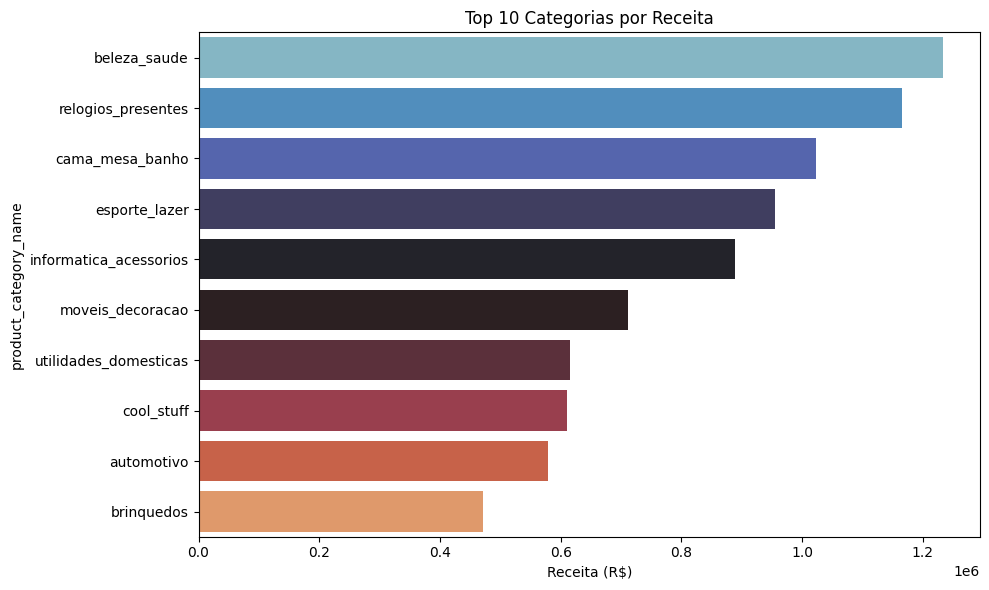

In [ ]:
# Usando as tabelas já tratadas pelo ETL global (célula anterior) — não recarregar do disco
orders = ped.copy()
items = itp.copy()
products = prd.copy()


# Juntar
df = items.merge(orders[['order_id', 'order_status']], on='order_id')
df = df[df['order_status'] == 'delivered']  # só pedidos entregues
df = df.merge(products[['product_id', 'product_category_name']], on='product_id')


# Agrupar por categoria em inglês
receita = df.groupby('product_category_name')['price'].sum().sort_values(ascending=False).head(10)

# Plotar
plt.figure(figsize=(10,6))
sns.barplot(x=receita.values, y=receita.index, palette='icefire')
plt.title('Top 10 Categorias por Receita')
plt.xlabel('Receita (R$)')
plt.tight_layout()
# plt.savefig('/content/q1.png', dpi=300, bbox_inches='tight') #(imprimir o gráfico)
plt.show()

---
##### versão em **Matplotlib** puro
---

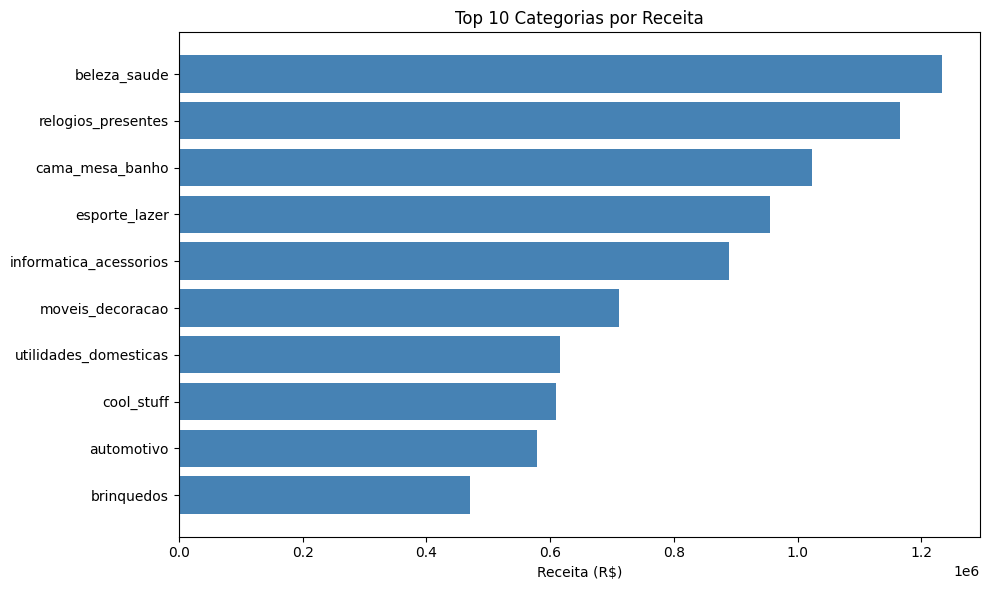

In [ ]:
# Usando as tabelas já tratadas pelo ETL global (célula anterior) — não recarregar do disco
orders = ped.copy()
items = itp.copy()
products = prd.copy()

# Juntar
df = items.merge(orders[['order_id', 'order_status']], on='order_id')
df = df[df['order_status'] == 'delivered']  # só pedidos entregues
df = df.merge(products[['product_id', 'product_category_name']], on='product_id')

# Agrupar por categoria
receita = df.groupby('product_category_name')['price'].sum().sort_values(ascending=False).head(10)

# Plotar com Matplotlib puro (gráfico de barras horizontais)
plt.figure(figsize=(10, 6))
plt.barh(receita.index, receita.values, color='steelblue')
plt.title('Top 10 Categorias por Receita')
plt.xlabel('Receita (R$)')
plt.gca().invert_yaxis()  # para que a maior receita fique no topo (opcional, mas igual ao seaborn)
plt.tight_layout()
plt.show()

### Relatório de dados

In [ ]:
# ============================================
# RELATÓRIO DE DADOS — Q1: Top 10 Categorias por Receita
# ============================================

receita_total_top10 = receita.sum()
receita_total_geral = df.groupby('product_category_name')['price'].sum().sum()
pct_top10_do_total = (receita_total_top10 / receita_total_geral) * 100

print(f"{'='*60}")
print(f"RELATÓRIO DE DADOS — Q1: TOP 10 CATEGORIAS POR RECEITA")
print(f"{'='*60}")

print(f"\n--- ESCOPO ---")
print(f"Pedidos analisados: {df['order_id'].nunique():,} (status: delivered)")
print(f"Itens analisados: {len(df):,}")
print(f"Categorias distintas no dataset: {df['product_category_name'].nunique():,}")

print(f"\n--- CONCENTRAÇÃO ---")
print(f"Receita total das top 10 categorias: R$ {receita_total_top10:,.2f}")
print(f"Receita total de todas as categorias: R$ {receita_total_geral:,.2f}")
print(f"Top 10 concentram: {pct_top10_do_total:.2f}% da receita total")

print(f"\n--- RANKING DETALHADO ---")
for i, (cat, valor) in enumerate(receita.items(), 1):
    pct_do_top10 = (valor / receita_total_top10) * 100
    pct_do_total = (valor / receita_total_geral) * 100
    print(f"  {i:2d}. {cat:35s} | R$ {valor:>12,.2f} | {pct_do_total:5.2f}% do total | {pct_do_top10:5.2f}% do top 10")

print(f"\n--- MÉTRICAS DE DISPERSÃO ---")
print(f"Receita média por categoria (top 10): R$ {receita.mean():,.2f}")
print(f"Receita mediana por categoria (top 10): R$ {receita.median():,.2f}")
print(f"Desvio padrão (top 10): R$ {receita.std():,.2f}")
print(f"Razão maior/menor (top 10): {receita.iloc[0] / receita.iloc[-1]:.2f}x")
print(f"{'='*60}")

RELATÓRIO DE DADOS — Q1: TOP 10 CATEGORIAS POR RECEITA

--- ESCOPO ---
Pedidos analisados: 96,478 (status: delivered)
Itens analisados: 110,197
Categorias distintas no dataset: 73

--- CONCENTRAÇÃO ---
Receita total das top 10 categorias: R$ 8,254,334.23
Receita total de todas as categorias: R$ 13,050,771.48
Top 10 concentram: 63.25% da receita total

--- RANKING DETALHADO ---
   1. beleza_saude                        | R$ 1,233,131.72 |  9.45% do total | 14.94% do top 10
   2. relogios_presentes                  | R$ 1,166,176.98 |  8.94% do total | 14.13% do top 10
   3. cama_mesa_banho                     | R$ 1,023,434.76 |  7.84% do total | 12.40% do top 10
   4. esporte_lazer                       | R$   954,852.55 |  7.32% do total | 11.57% do top 10
   5. informatica_acessorios              | R$   888,724.61 |  6.81% do total | 10.77% do top 10
   6. moveis_decoracao                    | R$   711,927.69 |  5.46% do total |  8.62% do top 10
   7. utilidades_domesticas           

---

## 2. Quais categorias têm maior taxa de cancelamento? Isso correlaciona com tempo entre compra e aprovação do pagamento?

**Tipo de Análise:** Diagnóstica  
**Técnicas:** Correlação de Pearson, scatter plot

**Visualização**  
Duas visualizações complementares: barras horizontais para ranking de taxa de cancelamento por categoria, e scatter plot para correlação entre tempo de aprovação e cancelamento. O par permite identificar categorias fora da curva e testar hipóteses de causalidade visualmente.

**Justificativa / Apoio à Decisão**  
O scatter plot testa hipóteses de causalidade visualmente: se o tempo de processamento de pagamento for fator de desistência, a empresa pode priorizar a revisão operacional do checkout nessas verticais.

---


/tmp/ipykernel_2839/1622149024.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='taxa_cancelamento', y='product_category_name', data=top_cancelamento, palette='rocket')


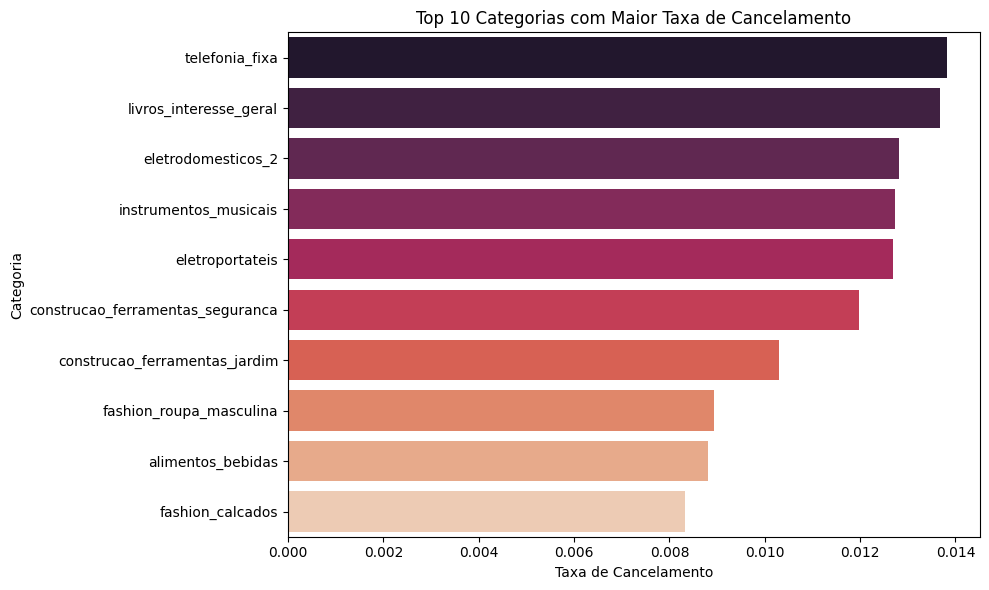

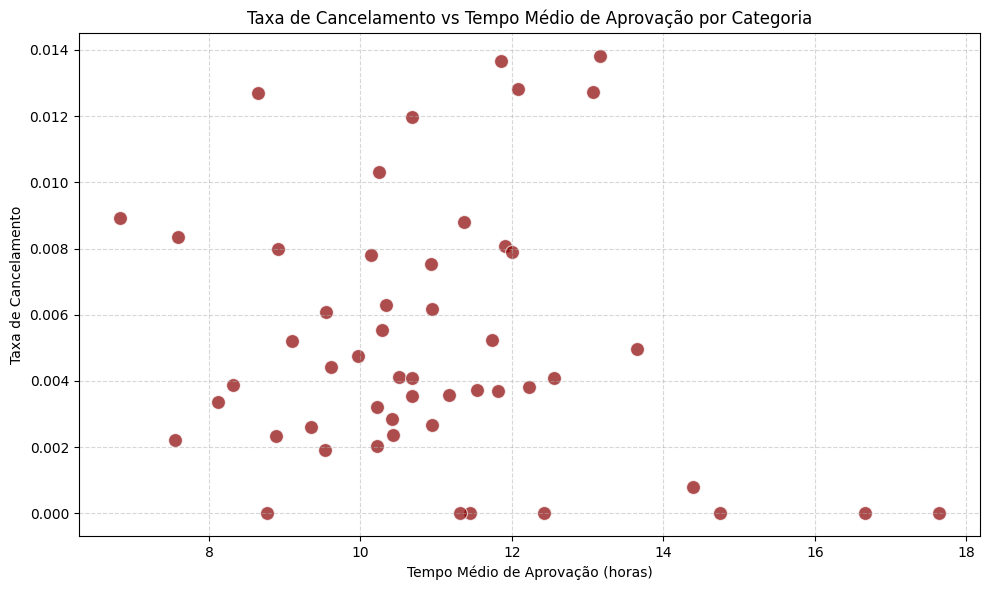

Correlação de Pearson entre Tempo de Aprovação e Taxa de Cancelamento: -0.1560


In [ ]:
# Usando as tabelas já tratadas pelo ETL global (célula anterior) — não recarregar do disco
orders = ped.copy()
items = itp.copy()
products = prd.copy()

# Converter datas para datetime
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_approved_at'] = pd.to_datetime(orders['order_approved_at'])

# Calcular tempo de aprovação (em horas)
orders['tempo_aprovacao_horas'] = (orders['order_approved_at'] - orders['order_purchase_timestamp']).dt.total_seconds() / 3600

# Juntar tabelas
df = items.merge(orders[['order_id', 'order_status', 'tempo_aprovacao_horas']], on='order_id')
df = df.merge(products[['product_id', 'product_category_name']], on='product_id')

# Calcular taxa de cancelamento por categoria
total_por_categoria = df.groupby('product_category_name')['order_id'].nunique().reset_index(name='total_pedidos')
cancelados_por_categoria = df[df['order_status'] == 'canceled'].groupby('product_category_name')['order_id'].nunique().reset_index(name='cancelados')

taxa_cancelamento = total_por_categoria.merge(cancelados_por_categoria, on='product_category_name', how='left')
taxa_cancelamento['cancelados'] = taxa_cancelamento['cancelados'].fillna(0)
taxa_cancelamento['taxa_cancelamento'] = taxa_cancelamento['cancelados'] / taxa_cancelamento['total_pedidos']

# Calcular tempo médio de aprovação por categoria (apenas pedidos não cancelados)
tempo_aprovacao = df[df['order_status'] != 'canceled'].groupby('product_category_name')['tempo_aprovacao_horas'].mean().reset_index(name='tempo_aprovacao_medio')

# Juntar
analise_cancelamento = taxa_cancelamento.merge(tempo_aprovacao, on='product_category_name', how='left')
analise_cancelamento = analise_cancelamento.sort_values('taxa_cancelamento', ascending=False)

# Filtrar categorias com pelo menos 100 pedidos para evitar ruído
analise_cancelamento = analise_cancelamento[analise_cancelamento['total_pedidos'] >= 100]

# Plot 1: Taxa de cancelamento por categoria (Top 10) — Seaborn
top_cancelamento = analise_cancelamento.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='taxa_cancelamento', y='product_category_name', data=top_cancelamento, palette='rocket')
plt.title('Top 10 Categorias com Maior Taxa de Cancelamento')
plt.xlabel('Taxa de Cancelamento')
plt.ylabel('Categoria')
plt.tight_layout()
# plt.savefig('/content/q2a.png', dpi=300, bbox_inches='tight') #(imprimir o gráfico)
plt.show()

# Plot 2: Correlação entre taxa de cancelamento e tempo de aprovação — Seaborn
plt.figure(figsize=(10, 6))
sns.scatterplot(x='tempo_aprovacao_medio', y='taxa_cancelamento', data=analise_cancelamento, color='darkred', s=100, alpha=0.7)
plt.title('Taxa de Cancelamento vs Tempo Médio de Aprovação por Categoria')
plt.xlabel('Tempo Médio de Aprovação (horas)')
plt.ylabel('Taxa de Cancelamento')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
# plt.savefig('/content/q2b.png', dpi=300, bbox_inches='tight') #(imprimir o gráfico)
plt.show()

# Correlação com NumPy
validos = analise_cancelamento.dropna(subset=['tempo_aprovacao_medio', 'taxa_cancelamento'])
corr = np.corrcoef(validos['tempo_aprovacao_medio'].values, validos['taxa_cancelamento'].values)[0, 1]
print(f"Correlação de Pearson entre Tempo de Aprovação e Taxa de Cancelamento: {corr:.4f}")

#### versão em Matplotlib puro

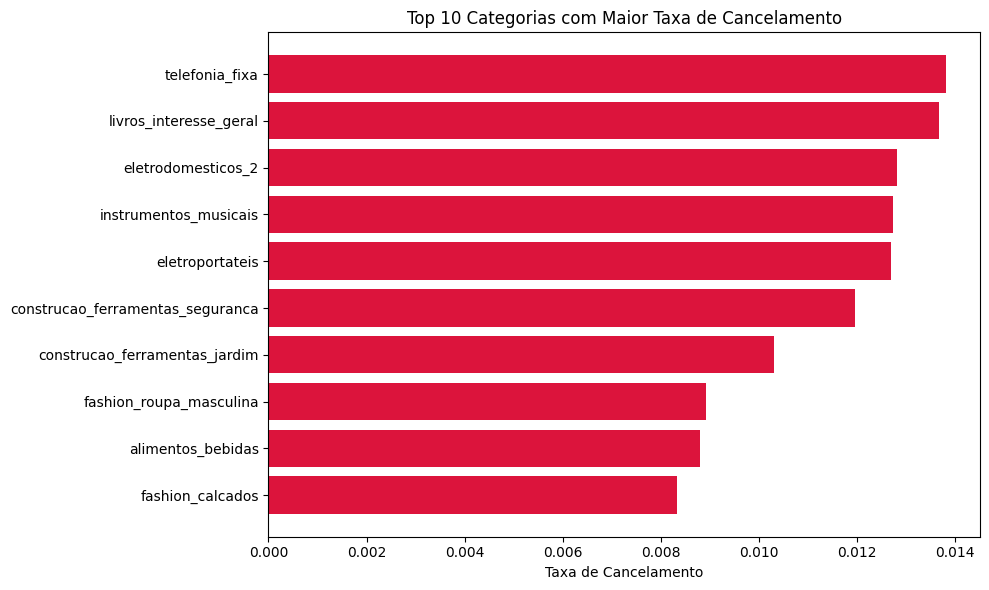

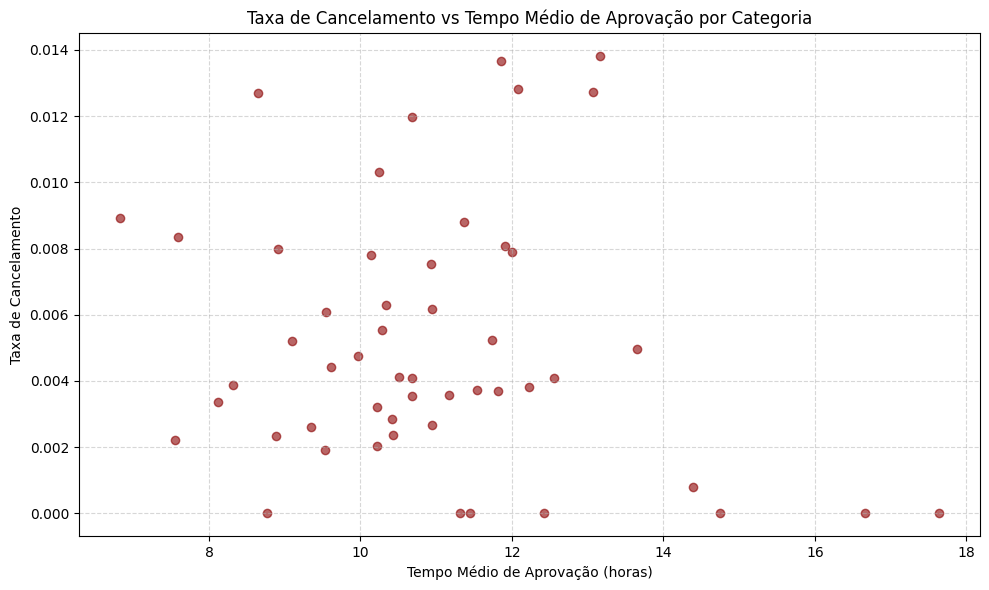

Correlação de Pearson entre Tempo de Aprovação e Taxa de Cancelamento: -0.1560


In [ ]:
# Usando as tabelas já tratadas pelo ETL global (célula anterior) — não recarregar do disco
orders = ped.copy()
items = itp.copy()
products = prd.copy()

# Converter datas para datetime
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_approved_at'] = pd.to_datetime(orders['order_approved_at'])

# Calcular tempo de aprovação (em horas)
orders['tempo_aprovacao_horas'] = (orders['order_approved_at'] - orders['order_purchase_timestamp']).dt.total_seconds() / 3600

# Juntar tabelas
df = items.merge(orders[['order_id', 'order_status', 'tempo_aprovacao_horas']], on='order_id')
df = df.merge(products[['product_id', 'product_category_name']], on='product_id')

# Calcular taxa de cancelamento por categoria
# Consideramos cancelados os pedidos com status != 'delivered' para simplificar,
# mas focamos especificamente em 'canceled'
total_por_categoria = df.groupby('product_category_name')['order_id'].nunique().reset_index(name='total_pedidos')
cancelados_por_categoria = df[df['order_status'] == 'canceled'].groupby('product_category_name')['order_id'].nunique().reset_index(name='cancelados')

taxa_cancelamento = total_por_categoria.merge(cancelados_por_categoria, on='product_category_name', how='left')
taxa_cancelamento['cancelados'] = taxa_cancelamento['cancelados'].fillna(0)
taxa_cancelamento['taxa_cancelamento'] = taxa_cancelamento['cancelados'] / taxa_cancelamento['total_pedidos']

# Calcular tempo médio de aprovação por categoria (apenas pedidos não cancelados, para não distorcer)
tempo_aprovacao = df[df['order_status'] != 'canceled'].groupby('product_category_name')['tempo_aprovacao_horas'].mean().reset_index(name='tempo_aprovacao_medio')

# Juntar
analise_cancelamento = taxa_cancelamento.merge(tempo_aprovacao, on='product_category_name', how='left')
analise_cancelamento = analise_cancelamento.sort_values('taxa_cancelamento', ascending=False)

# Filtrar categorias com pelo menos 100 pedidos para evitar ruído
analise_cancelamento = analise_cancelamento[analise_cancelamento['total_pedidos'] >= 100]

# Plot 1: Taxa de cancelamento por categoria (Top 10)
top_cancelamento = analise_cancelamento.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_cancelamento['product_category_name'], top_cancelamento['taxa_cancelamento'], color='crimson')
plt.title('Top 10 Categorias com Maior Taxa de Cancelamento')
plt.xlabel('Taxa de Cancelamento')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Plot 2: Correlação entre taxa de cancelamento e tempo de aprovação
plt.figure(figsize=(10, 6))
plt.scatter(analise_cancelamento['tempo_aprovacao_medio'], analise_cancelamento['taxa_cancelamento'], alpha=0.6, color='darkred')
plt.title('Taxa de Cancelamento vs Tempo Médio de Aprovação por Categoria')
plt.xlabel('Tempo Médio de Aprovação (horas)')
plt.ylabel('Taxa de Cancelamento')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Correlação com NumPy
validos = analise_cancelamento.dropna(subset=['tempo_aprovacao_medio', 'taxa_cancelamento'])
corr = np.corrcoef(validos['tempo_aprovacao_medio'].values, validos['taxa_cancelamento'].values)[0, 1]
print(f"Correlação de Pearson entre Tempo de Aprovação e Taxa de Cancelamento: {corr:.4f}")


### Relatório de dados
---


In [ ]:
# ============================================
# RELATÓRIO DE DADOS — Q2: Taxa de Cancelamento por Categoria × Tempo de Aprovação
# ============================================

print(f"{'='*60}")
print(f"RELATÓRIO DE DADOS — Q2: CANCELAMENTO × TEMPO DE APROVAÇÃO")
print(f"{'='*60}")

print(f"\n--- ESCOPO ---")
print(f"Total de pedidos analisados: {df['order_id'].nunique():,}")
print(f"Categorias com ≥100 pedidos: {len(analise_cancelamento):,}")
print(f"Pedidos cancelados no escopo: {int(analise_cancelamento['cancelados'].sum()):,}")
print(f"Taxa de cancelamento geral: {(analise_cancelamento['cancelados'].sum() / analise_cancelamento['total_pedidos'].sum()) * 100:.2f}%")

print(f"\n--- CORRELAÇÃO ---")
print(f"Coeficiente de Pearson: {corr:.4f}")
print(f"Interpretação: {'Fraca negativa' if abs(corr) < 0.3 else 'Moderada' if abs(corr) < 0.7 else 'Forte'} {'negativa' if corr < 0 else 'positiva'}")

print(f"\n--- TEMPO DE APROVAÇÃO (TODAS AS CATEGORIAS) ---")
tempo_medio_geral = validos['tempo_aprovacao_medio'].mean()
tempo_mediana_geral = validos['tempo_aprovacao_medio'].median()
print(f"Tempo médio de aprovação: {tempo_medio_geral:.2f} horas")
print(f"Tempo mediano de aprovação: {tempo_mediana_geral:.2f} horas")
print(f"Desvio padrão: {validos['tempo_aprovacao_medio'].std():.2f} horas")
print(f"Mínimo: {validos['tempo_aprovacao_medio'].min():.2f} horas")
print(f"Máximo: {validos['tempo_aprovacao_medio'].max():.2f} horas")

print(f"\n--- TAXA DE CANCELAMENTO (TODAS AS CATEGORIAS) ---")
taxa_media_geral = analise_cancelamento['taxa_cancelamento'].mean()
taxa_mediana_geral = analise_cancelamento['taxa_cancelamento'].median()
print(f"Taxa média de cancelamento: {taxa_media_geral * 100:.2f}%")
print(f"Taxa mediana de cancelamento: {taxa_mediana_geral * 100:.2f}%")
print(f"Desvio padrão: {analise_cancelamento['taxa_cancelamento'].std() * 100:.2f} p.p.")
print(f"Mínimo: {analise_cancelamento['taxa_cancelamento'].min() * 100:.2f}%")
print(f"Máximo: {analise_cancelamento['taxa_cancelamento'].max() * 100:.2f}%")

print(f"\n--- TOP 10 CATEGORIAS COM MAIOR TAXA DE CANCELAMENTO ---")
for i, row in top_cancelamento.iterrows():
    print(f"  {int(row.name) + 1:2d}. {row['product_category_name']:35s} | {row['taxa_cancelamento'] * 100:5.2f}% cancel | {row['total_pedidos']:>6,} pedidos | {row['tempo_aprovacao_medio']:6.2f}h aprovação")

print(f"\n--- CATEGORIAS COM MAIOR TEMPO DE APROVAÇÃO (TOP 5) ---")
top_tempo = analise_cancelamento.nlargest(5, 'tempo_aprovacao_medio')
for i, row in top_tempo.iterrows():
    print(f"  {row['product_category_name']:35s} | {row['tempo_aprovacao_medio']:6.2f}h | {row['taxa_cancelamento'] * 100:5.2f}% cancel")

print(f"\n--- CATEGORIAS COM MENOR TEMPO DE APROVAÇÃO (TOP 5) ---")
bottom_tempo = analise_cancelamento.nsmallest(5, 'tempo_aprovacao_medio')
for i, row in bottom_tempo.iterrows():
    print(f"  {row['product_category_name']:35s} | {row['tempo_aprovacao_medio']:6.2f}h | {row['taxa_cancelamento'] * 100:5.2f}% cancel")

print(f"\n--- CATEGORIAS FORA DA CURVA (>2 DESVIOS) ---")
limite_superior = taxa_media_geral + (2 * analise_cancelamento['taxa_cancelamento'].std())
outliers = analise_cancelamento[analise_cancelamento['taxa_cancelamento'] > limite_superior]
print(f"Threshold (média + 2σ): {limite_superior * 100:.2f}%")
print(f"Categorias acima do threshold: {len(outliers)}")
for _, row in outliers.iterrows():
    print(f"  {row['product_category_name']:35s} | {row['taxa_cancelamento'] * 100:5.2f}% | {row['total_pedidos']:>6,} pedidos")

print(f"{'='*60}")

RELATÓRIO DE DADOS — Q2: CANCELAMENTO × TEMPO DE APROVAÇÃO

--- ESCOPO ---
Total de pedidos analisados: 98,666
Categorias com ≥100 pedidos: 51
Pedidos cancelados no escopo: 443
Taxa de cancelamento geral: 0.46%

--- CORRELAÇÃO ---
Coeficiente de Pearson: -0.1560
Interpretação: Fraca negativa negativa

--- TEMPO DE APROVAÇÃO (TODAS AS CATEGORIAS) ---
Tempo médio de aprovação: 10.92 horas
Tempo mediano de aprovação: 10.68 horas
Desvio padrão: 2.11 horas
Mínimo: 6.82 horas
Máximo: 17.64 horas

--- TAXA DE CANCELAMENTO (TODAS AS CATEGORIAS) ---
Taxa média de cancelamento: 0.52%
Taxa mediana de cancelamento: 0.41%
Desvio padrão: 0.39 p.p.
Mínimo: 0.00%
Máximo: 1.38%

--- TOP 10 CATEGORIAS COM MAIOR TAXA DE CANCELAMENTO ---
  72. telefonia_fixa                      |  1.38% cancel |    217 pedidos |  13.16h aprovação
  49. livros_interesse_geral              |  1.37% cancel |    512 pedidos |  11.86h aprovação
  30. eletrodomesticos_2                  |  1.28% cancel |    234 pedidos |  12.0

---

## 3. Quantos clientes compram mais de uma vez? Qual o tempo médio entre compras?

**Tipo de Análise:** Descritiva  
**Técnicas:** Recorrência, distribuição log, histograma

**Visualização**  
Barras verticais em escala logarítmica para distribuição de número de compras por cliente, e histograma com curva de densidade para intervalo entre compras. A escala log revela a raridade da recorrência; o histograma expõe a bimodalidade do comportamento (impulso vs. relembrança).

**Justificativa / Apoio à Decisão**  
A escala logarítmica revela a raridade da recorrência; o histograma de intervalos expõe a bimodalidade do comportamento (impulso vs. relembrança), definindo a janela temporal para disparo de remarketing.

---


Total de clientes únicos: 94688
Clientes recorrentes (>1 compra): 2872 (3.03%)
Clientes novos (1 compra): 91816 (96.97%)
Tempo médio entre compras: 78.5 dias
Mediana do tempo entre compras: 29.0 dias


/tmp/ipykernel_2839/3230603139.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='num_compras', y='qtd_clientes', data=compras_dist.head(10), palette='mako')


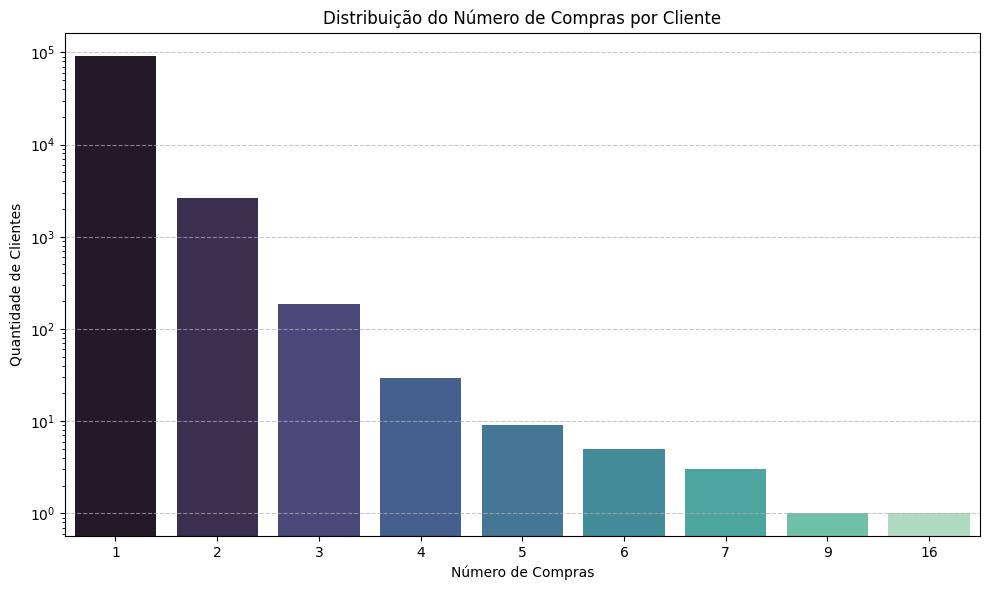

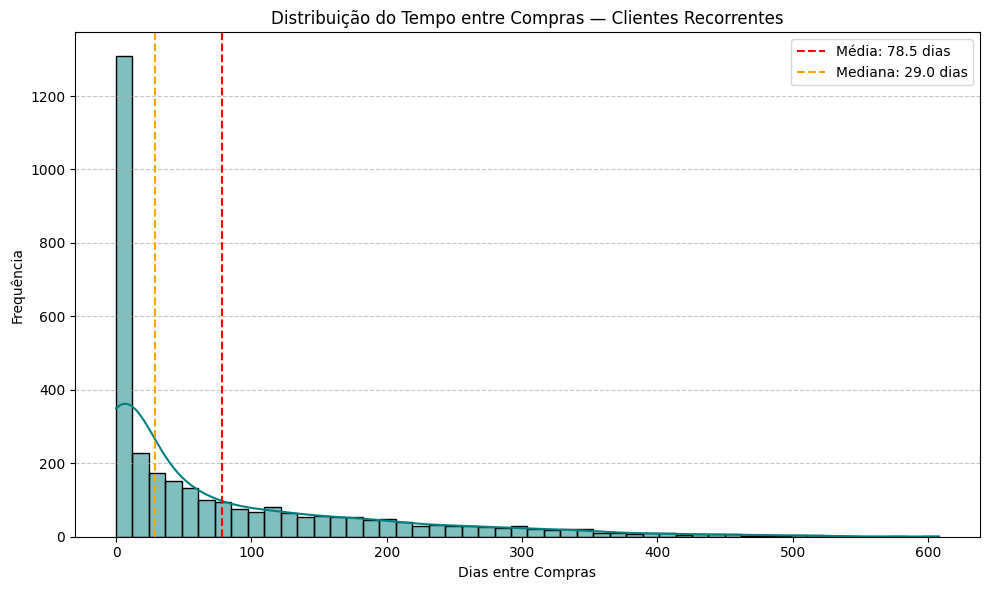

In [ ]:
# Usando as tabelas já tratadas pelo ETL global (célula anterior) — não recarregar do disco
orders = ped.copy()
customers = clt.copy()

# Converter data para datetime
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

# Juntar para ter customer_unique_id
df = orders.merge(customers[['customer_id', 'customer_unique_id']], on='customer_id')

# Filtrar apenas pedidos entregues ou aprovados (excluir cancelados para análise de recorrência real)
df = df[df['order_status'].isin(['delivered', 'shipped', 'processing', 'approved'])]

# Ordenar por cliente e data
df = df.sort_values(['customer_unique_id', 'order_purchase_timestamp'])

# Contar compras por cliente
compras_por_cliente = df.groupby('customer_unique_id').agg(
    total_compras=('order_id', 'nunique'),
    primeira_compra=('order_purchase_timestamp', 'min'),
    ultima_compra=('order_purchase_timestamp', 'max')
).reset_index()

# Calcular recorrência
recorrentes = compras_por_cliente[compras_por_cliente['total_compras'] > 1]
novos = compras_por_cliente[compras_por_cliente['total_compras'] == 1]

total_clientes = len(compras_por_cliente)
total_recorrentes = len(recorrentes)
percentual_recorrentes = total_recorrentes / total_clientes * 100

print(f"Total de clientes únicos: {total_clientes}")
print(f"Clientes recorrentes (>1 compra): {total_recorrentes} ({percentual_recorrentes:.2f}%)")
print(f"Clientes novos (1 compra): {len(novos)} ({100 - percentual_recorrentes:.2f}%)")

# Calcular tempo médio entre compras para recorrentes
tempos_entre_compras = []
for cliente in recorrentes['customer_unique_id']:
    datas_cliente = df[df['customer_unique_id'] == cliente]['order_purchase_timestamp'].sort_values()
    deltas = datas_cliente.diff().dropna()
    for delta in deltas:
        tempos_entre_compras.append(delta.days)

if tempos_entre_compras:
    tempo_medio = np.mean(tempos_entre_compras)
    tempo_mediana = np.median(tempos_entre_compras)
    print(f"Tempo médio entre compras: {tempo_medio:.1f} dias")
    print(f"Mediana do tempo entre compras: {tempo_mediana:.1f} dias")

# Plot 1: Distribuição de número de compras por cliente — Seaborn
compras_dist = compras_por_cliente['total_compras'].value_counts().sort_index().reset_index()
compras_dist.columns = ['num_compras', 'qtd_clientes']

plt.figure(figsize=(10, 6))
sns.barplot(x='num_compras', y='qtd_clientes', data=compras_dist.head(10), palette='mako')
plt.title('Distribuição do Número de Compras por Cliente')
plt.xlabel('Número de Compras')
plt.ylabel('Quantidade de Clientes')
plt.yscale('log')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
# plt.savefig('/content/q3a.png', dpi=300, bbox_inches='tight') #(imprimir o gráfico)
plt.show()

# Plot 2: Histograma do tempo entre compras (recorrentes) — Seaborn
if tempos_entre_compras:
    plt.figure(figsize=(10, 6))
    sns.histplot(tempos_entre_compras, bins=50, color='teal', kde=True)
    plt.title('Distribuição do Tempo entre Compras — Clientes Recorrentes')
    plt.xlabel('Dias entre Compras')
    plt.ylabel('Frequência')
    plt.axvline(tempo_medio, color='red', linestyle='--', label=f'Média: {tempo_medio:.1f} dias')
    plt.axvline(tempo_mediana, color='orange', linestyle='--', label=f'Mediana: {tempo_mediana:.1f} dias')
    plt.legend()
    plt.grid(True, axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    # plt.savefig('/content/q3b.png', dpi=300, bbox_inches='tight') #(imprimir o gráfico)
    plt.show()

---
##### versão em **Matplotlib** puro
---

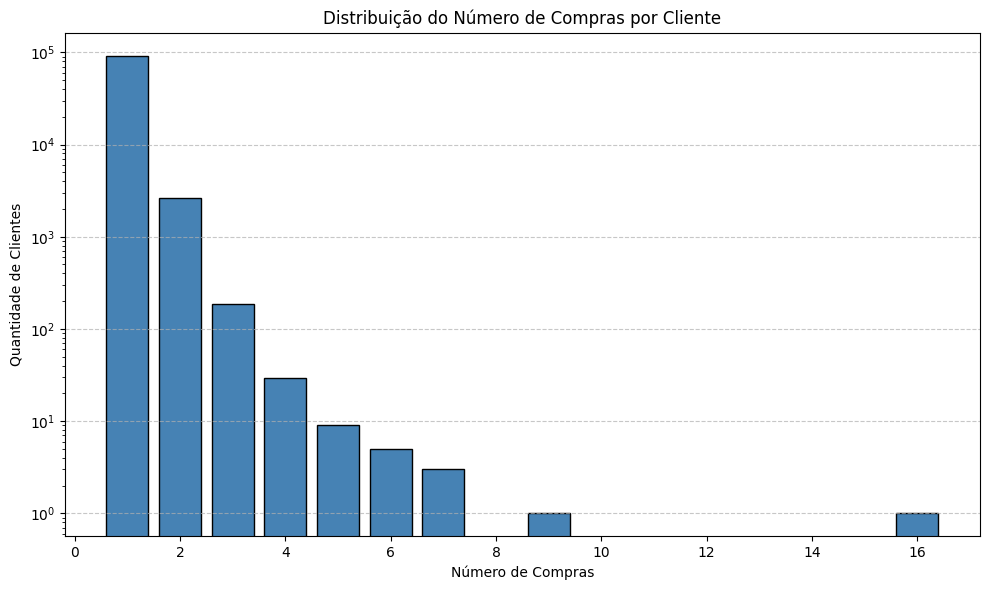

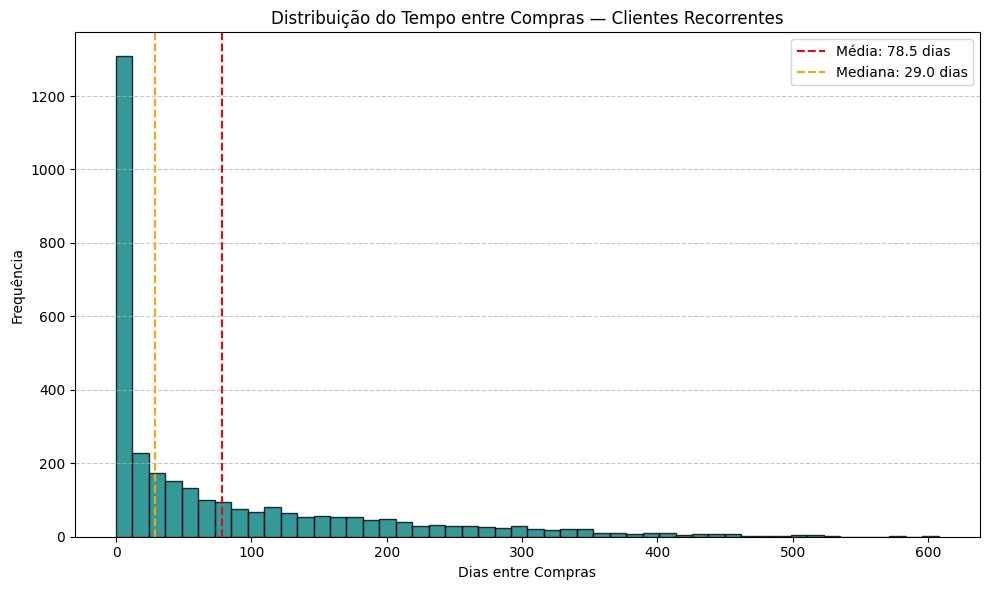

In [ ]:
# Plot 1: Distribuição de número de compras por cliente — Matplotlib puro
compras_dist_mp = compras_por_cliente['total_compras'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
plt.bar(compras_dist_mp.index[:10], compras_dist_mp.values[:10], color='steelblue', edgecolor='black')
plt.title('Distribuição do Número de Compras por Cliente')
plt.xlabel('Número de Compras')
plt.ylabel('Quantidade de Clientes')
plt.yscale('log')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Plot 2: Histograma do tempo entre compras (recorrentes) — Matplotlib puro
if tempos_entre_compras:
    plt.figure(figsize=(10, 6))
    plt.hist(tempos_entre_compras, bins=50, color='teal', edgecolor='black', alpha=0.8)
    plt.title('Distribuição do Tempo entre Compras — Clientes Recorrentes')
    plt.xlabel('Dias entre Compras')
    plt.ylabel('Frequência')
    plt.axvline(tempo_medio, color='red', linestyle='--', label=f'Média: {tempo_medio:.1f} dias')
    plt.axvline(tempo_mediana, color='orange', linestyle='--', label=f'Mediana: {tempo_mediana:.1f} dias')
    plt.legend()
    plt.grid(True, axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

### Relatórrio de dados
---

In [ ]:
# ============================================
# RELATÓRIO DE DADOS — Q3: Recorrência de Clientes
# ============================================

print(f"{'='*60}")
print(f"RELATÓRIO DE DADOS — Q3: RECORRÊNCIA DE CLIENTES")
print(f"{'='*60}")

print(f"\n--- ESCOPO ---")
print(f"Pedidos analisados: {df['order_id'].nunique():,}")
print(f"Clientes únicos: {total_clientes:,}")
print(f"Status considerados: delivered, shipped, processing, approved")
print(f"Período: {compras_por_cliente['primeira_compra'].min().strftime('%Y-%m-%d')} a {compras_por_cliente['ultima_compra'].max().strftime('%Y-%m-%d')}")

print(f"\n--- RECORRÊNCIA ---")
print(f"Clientes recorrentes (>1 compra): {total_recorrentes:,} ({percentual_recorrentes:.2f}%)")
print(f"Clientes novos (1 compra): {len(novos):,} ({100 - percentual_recorrentes:.2f}%)")
print(f"Taxa de recorrência: 1 em cada {total_clientes / total_recorrentes:.0f} clientes" if total_recorrentes > 0 else "Taxa de recorrência: 0%")

print(f"\n--- DISTRIBUIÇÃO DE COMPRAS POR CLIENTE ---")
for _, row in compras_dist.head(10).iterrows():
    pct_clientes = (row['qtd_clientes'] / total_clientes) * 100
    print(f"  {int(row['num_compras']):2d} compra(s): {int(row['qtd_clientes']):>7,} clientes ({pct_clientes:5.2f}%)")

print(f"\n--- CLIENTES COM 3+ COMPRAS ---")
compras_3mais = compras_dist[compras_dist['num_compras'] >= 3]
total_3mais = compras_3mais['qtd_clientes'].sum()
print(f"Clientes com 3+ compras: {int(total_3mais):,} ({(total_3mais / total_clientes) * 100:.2f}%)")
if len(compras_3mais) > 0:
    print(f"Máximo de compras por cliente: {int(compras_dist['num_compras'].max())}")

print(f"\n--- TEMPO ENTRE COMPRAS (RECORRENTES) ---")
if tempos_entre_compras:
    print(f"Intervalos calculados: {len(tempos_entre_compras):,}")
    print(f"Tempo médio entre compras: {tempo_medio:.1f} dias")
    print(f"Tempo mediano entre compras: {tempo_mediana:.1f} dias")
    print(f"Desvio padrão: {np.std(tempos_entre_compras):.1f} dias")
    print(f"Mínimo: {min(tempos_entre_compras)} dias")
    print(f"Máximo: {max(tempos_entre_compras)} dias")
    print(f"Percentil 25: {np.percentile(tempos_entre_compras, 25):.1f} dias")
    print(f"Percentil 75: {np.percentile(tempos_entre_compras, 75):.1f} dias")
    print(f"Clientes recorrentes com intervalo ≤30 dias: {sum(1 for t in tempos_entre_compras if t <= 30):,} ({(sum(1 for t in tempos_entre_compras if t <= 30) / len(tempos_entre_compras)) * 100:.1f}%)")
    print(f"Clientes recorrentes com intervalo >365 dias: {sum(1 for t in tempos_entre_compras if t > 365):,} ({(sum(1 for t in tempos_entre_compras if t > 365) / len(tempos_entre_compras)) * 100:.1f}%)")
else:
    print(f"Nenhum cliente recorrente com múltiplos intervalos calculáveis")

print(f"\n--- COORTE DE RECORRÊNCIA ---")
if total_recorrentes > 0:
    recorrencia_2x = compras_dist[compras_dist['num_compras'] == 2]['qtd_clientes'].sum()
    recorrencia_3xmais = compras_dist[compras_dist['num_compras'] >= 3]['qtd_clientes'].sum()
    print(f"Recorrentes com exatamente 2 compras: {int(recorrencia_2x):,} ({(recorrencia_2x / total_recorrentes) * 100:.1f}% dos recorrentes)")
    print(f"Recorrentes com 3+ compras: {int(recorrencia_3xmais):,} ({(recorrencia_3xmais / total_recorrentes) * 100:.1f}% dos recorrentes)")

print(f"{'='*60}")

RELATÓRIO DE DADOS — Q3: RECORRÊNCIA DE CLIENTES

--- ESCOPO ---
Pedidos analisados: 98,666
Clientes únicos: 94,688
Status considerados: delivered, shipped, processing, approved
Período: 2016-09-04 a 2018-09-03

--- RECORRÊNCIA ---
Clientes recorrentes (>1 compra): 2,872 (3.03%)
Clientes novos (1 compra): 91,816 (96.97%)
Taxa de recorrência: 1 em cada 33 clientes

--- DISTRIBUIÇÃO DE COMPRAS POR CLIENTE ---
   1 compra(s):  91,816 clientes (96.97%)
   2 compra(s):   2,637 clientes ( 2.78%)
   3 compra(s):     187 clientes ( 0.20%)
   4 compra(s):      29 clientes ( 0.03%)
   5 compra(s):       9 clientes ( 0.01%)
   6 compra(s):       5 clientes ( 0.01%)
   7 compra(s):       3 clientes ( 0.00%)
   9 compra(s):       1 clientes ( 0.00%)
  16 compra(s):       1 clientes ( 0.00%)

--- CLIENTES COM 3+ COMPRAS ---
Clientes com 3+ compras: 235 (0.25%)
Máximo de compras por cliente: 16

--- TEMPO ENTRE COMPRAS (RECORRENTES) ---
Intervalos calculados: 3,200
Tempo médio entre compras: 78.5 dia

---

## 4. Clientes recorrentes migram de categoria ou ficam fiéis à mesma?

**Tipo de Análise:** Comportamental  
**Técnicas:** Transições de estado, pizza, barras

**Visualização**  
Gráfico de pizza para proporção de migração vs. fidelidade, e barras horizontais para top transições de categoria. A pizza sintetiza comportamento geral; as barras detalham o caminho mais frequente entre verticais.

**Justificativa / Apoio à Decisão**  
A pizza sintetiza o comportamento geral; as barras detalham o caminho mais frequente entre verticais. Orienta se o algoritmo de recomendação deve priorizar profundidade no nicho ou diversificação sequencial (cross-sell).

---


Clientes recorrentes analisados: 2872
Migram de categoria: 1618 (56.34%)
Ficam fiéis à primeira categoria: 1254 (43.66%)


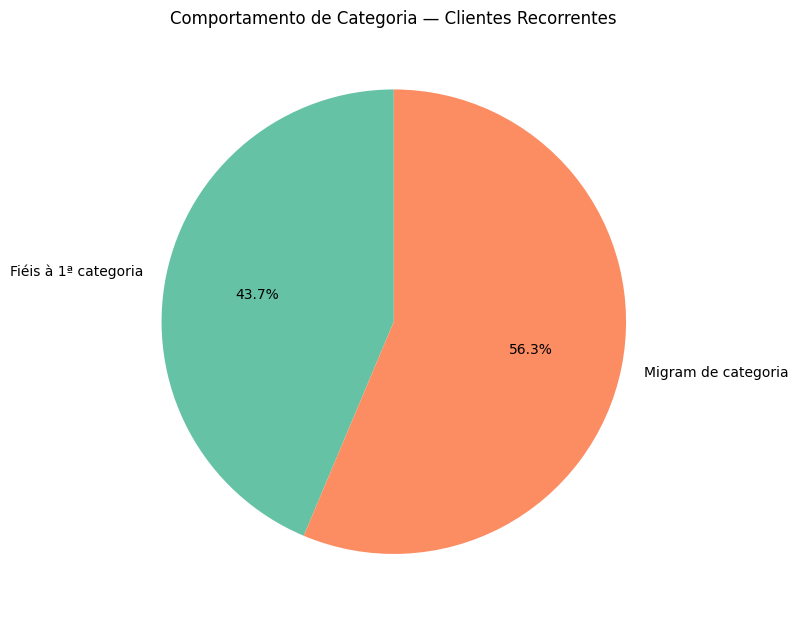


Top 10 transições de categoria (primeira → última compra):
  moveis_decoracao → cama_mesa_banho: 39 clientes
  cama_mesa_banho → moveis_decoracao: 34 clientes
  cama_mesa_banho → cama_mesa_banho: 25 clientes
  moveis_decoracao → utilidades_domesticas: 18 clientes
  utilidades_domesticas → cama_mesa_banho: 18 clientes
  cama_mesa_banho → utilidades_domesticas: 17 clientes
  ferramentas_jardim → moveis_decoracao: 17 clientes
  cama_mesa_banho → informatica_acessorios: 13 clientes
  utilidades_domesticas → moveis_decoracao: 12 clientes
  moveis_decoracao → ferramentas_jardim: 12 clientes


/tmp/ipykernel_2839/3687258053.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='contagem', y='transicao', data=transicoes_top, palette='coolwarm')


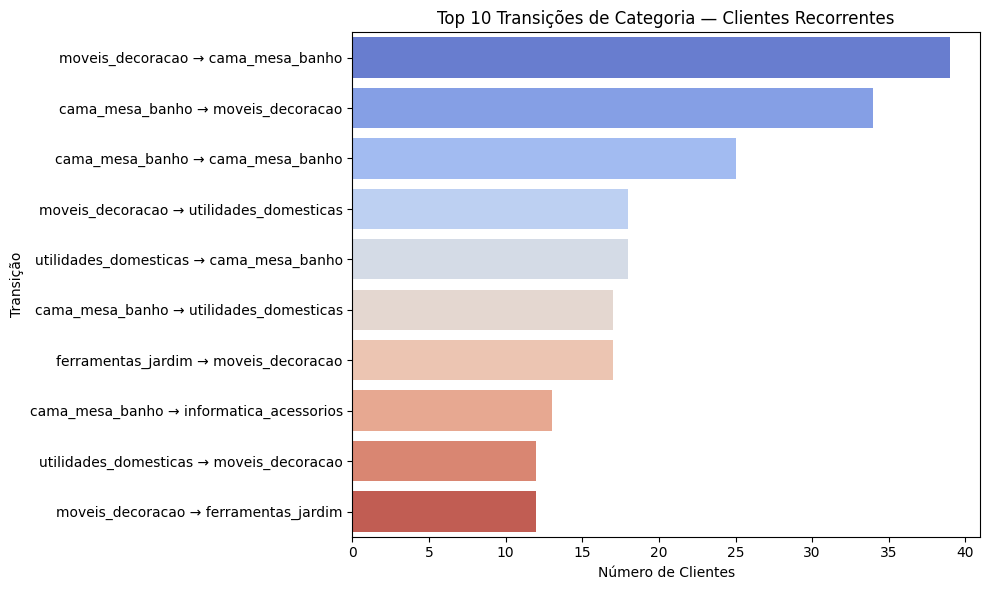

In [ ]:
# Usando as tabelas já tratadas pelo ETL global (célula anterior) — não recarregar do disco
orders = ped.copy()
customers = clt.copy()
items = itp.copy()
products = prd.copy()

# Converter data
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

# Juntar todas as tabelas
df = orders.merge(customers[['customer_id', 'customer_unique_id']], on='customer_id')
df = df.merge(items[['order_id', 'product_id']], on='order_id')
df = df.merge(products[['product_id', 'product_category_name']], on='product_id')

# Filtrar pedidos válidos (não cancelados)
df = df[df['order_status'].isin(['delivered', 'shipped', 'processing', 'approved'])]

# Ordenar por cliente e data
df = df.sort_values(['customer_unique_id', 'order_purchase_timestamp'])

# Identificar primeira categoria de cada cliente
primeira_compra = df.groupby('customer_unique_id').first()[['product_category_name']].reset_index()
primeira_compra.columns = ['customer_unique_id', 'primeira_categoria']

# Clientes recorrentes (>1 compra)
contagem_compras = df.groupby('customer_unique_id')['order_id'].nunique().reset_index(name='total_compras')
recorrentes = contagem_compras[contagem_compras['total_compras'] > 1]['customer_unique_id']

# Para cada recorrente, verificar se comprou em categorias diferentes da primeira
df_recorrentes = df[df['customer_unique_id'].isin(recorrentes)]
df_recorrentes = df_recorrentes.merge(primeira_compra, on='customer_unique_id')

# Flag: comprou em categoria diferente da primeira?
df_recorrentes['migrou'] = df_recorrentes['product_category_name'] != df_recorrentes['primeira_categoria']

# Agregar por cliente: alguma compra foi em categoria diferente?
migracao = df_recorrentes.groupby('customer_unique_id')['migrou'].max().reset_index(name='migrou_de_categoria')

# Contar
migraram = migracao['migrou_de_categoria'].sum()
ficaram = len(migracao) - migraram
percentual_migraram = migraram / len(migracao) * 100
percentual_ficaram = ficaram / len(migracao) * 100

print(f"Clientes recorrentes analisados: {len(migracao)}")
print(f"Migram de categoria: {migraram} ({percentual_migraram:.2f}%)")
print(f"Ficam fiéis à primeira categoria: {ficaram} ({percentual_ficaram:.2f}%)")

# Plot: Pizza mostrando proporção de migração vs fidelidade — Seaborn (via matplotlib com paleta seaborn)
plt.figure(figsize=(8, 8))
colors = sns.color_palette("Set2", 2)
plt.pie([ficaram, migraram], labels=['Fiéis à 1ª categoria', 'Migram de categoria'],
        autopct='%1.1f%%', startangle=90, colors=colors)
plt.title('Comportamento de Categoria — Clientes Recorrentes')
plt.tight_layout()
#plt.savefig('/content/q4a.png', dpi=300, bbox_inches='tight') #(imprimir o gráfico)
plt.show()

# Análise adicional: para quem migra, quais são as transições mais comuns?
clientes_migraram = migracao[migracao['migrou_de_categoria'] == True]['customer_unique_id']
transicoes = df_recorrentes[df_recorrentes['customer_unique_id'].isin(clientes_migraram)]

# Primeira categoria vs categoria atual (última compra)
ultima_compra = transicoes.groupby('customer_unique_id').last()[['primeira_categoria', 'product_category_name']].reset_index()
ultima_compra.columns = ['customer_unique_id', 'primeira_categoria', 'ultima_categoria']

# Top transições
transicoes_top = ultima_compra.groupby(['primeira_categoria', 'ultima_categoria']).size().reset_index(name='contagem')
transicoes_top = transicoes_top.sort_values('contagem', ascending=False).head(10)

print("\nTop 10 transições de categoria (primeira → última compra):")
for _, row in transicoes_top.iterrows():
    print(f"  {row['primeira_categoria']} → {row['ultima_categoria']}: {row['contagem']} clientes")

# Plot: Top transições — Seaborn
plt.figure(figsize=(10, 6))
transicoes_top['transicao'] = transicoes_top['primeira_categoria'] + ' → ' + transicoes_top['ultima_categoria']
sns.barplot(x='contagem', y='transicao', data=transicoes_top, palette='coolwarm')
plt.title('Top 10 Transições de Categoria — Clientes Recorrentes')
plt.xlabel('Número de Clientes')
plt.ylabel('Transição')
plt.tight_layout()
#plt.savefig('/content/q4b.png', dpi=300, bbox_inches='tight') #(imprimir o gráfico)
plt.show()

---
##### versão em **Matplotlib** puro
---

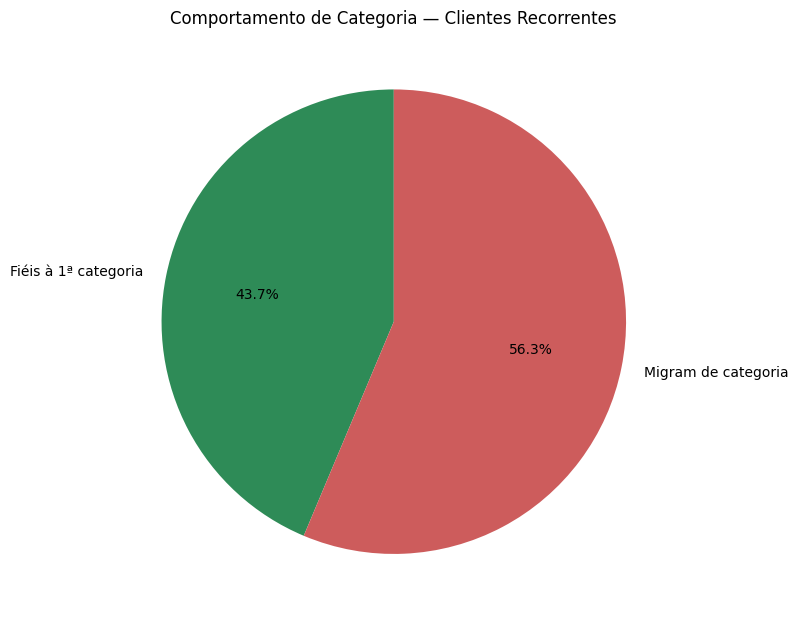

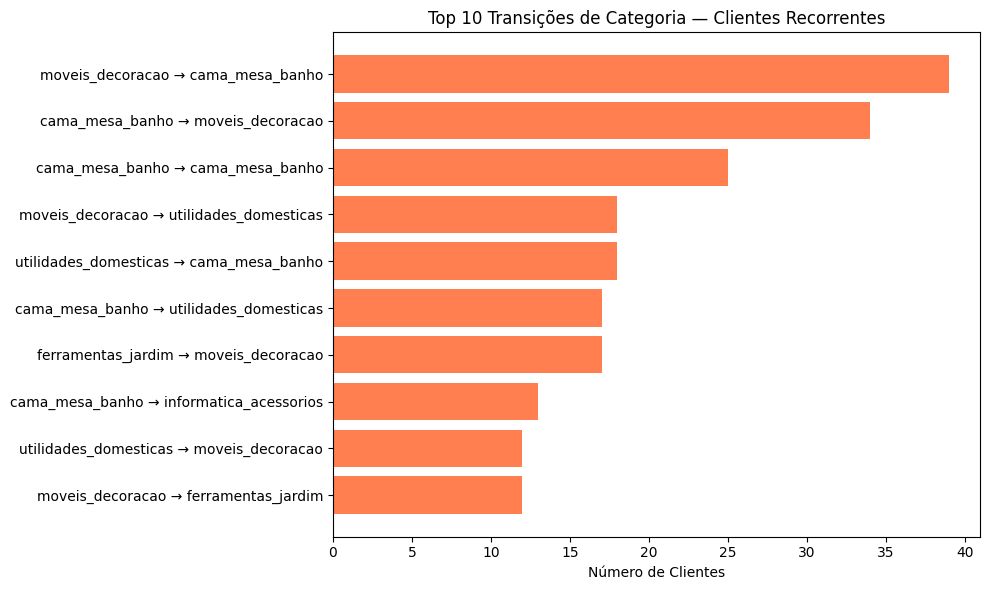

In [ ]:
# Plot: Pizza — Matplotlib puro
plt.figure(figsize=(8, 8))
plt.pie([ficaram, migraram], labels=['Fiéis à 1ª categoria', 'Migram de categoria'],
        autopct='%1.1f%%', startangle=90, colors=['#2E8B57', '#CD5C5C'])
plt.title('Comportamento de Categoria — Clientes Recorrentes')
plt.tight_layout()
plt.show()

# Plot: Top transições — Matplotlib puro
plt.figure(figsize=(10, 6))
plt.barh(transicoes_top['transicao'], transicoes_top['contagem'], color='coral')
plt.title('Top 10 Transições de Categoria — Clientes Recorrentes')
plt.xlabel('Número de Clientes')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Relatório de dados
---

In [ ]:
# ============================================
# RELATÓRIO DE DADOS — Q4: Migração de Categoria por Clientes Recorrentes
# ============================================

print(f"{'='*60}")
print(f"RELATÓRIO DE DADOS — Q4: MIGRAÇÃO DE CATEGORIA — CLIENTES RECORRENTES")
print(f"{'='*60}")

print(f"\n--- ESCOPO ---")
print(f"Clientes recorrentes analisados: {len(migracao):,}")
print(f"Total de compras no escopo: {df['order_id'].nunique():,}")
print(f"Categorias distintas: {df['product_category_name'].nunique():,}")
print(f"Período: {orders['order_purchase_timestamp'].min()} a {orders['order_purchase_timestamp'].max()}")

print(f"\n--- COMPORTAMENTO GERAL ---")
print(f"Migram de categoria: {migraram:,} ({percentual_migraram:.2f}%)")
print(f"Fiéis à primeira categoria: {ficaram:,} ({percentual_ficaram:.2f}%)")
print(f"Razão migração/fidelidade: {migraram / ficaram:.2f}x" if ficaram > 0 else "Razão: indefinida (zero fiéis)")

print(f"\n--- TOP 10 TRANSIÇÕES (PRIMEIRA → ÚLTIMA COMPRA) ---")
for i, row in transicoes_top.iterrows():
    pct_dos_migrantes = (row['contagem'] / migraram) * 100
    print(f"  {i + 1:2d}. {row['primeira_categoria']:30s} → {row['ultima_categoria']:30s} | {int(row['contagem']):>3} clientes ({pct_dos_migrantes:4.1f}% dos migrantes)")

print(f"\n--- CATEGORIAS DE ENTRADA MAIS COMUNS (PRIMEIRA COMPRA) ---")
entrada_freq = ultima_compra['primeira_categoria'].value_counts().head(5)
for cat, qtd in entrada_freq.items():
    pct = (qtd / len(ultima_compra)) * 100
    print(f"  {cat:35s} | {int(qtd):>4} clientes ({pct:5.1f}%)")

print(f"\n--- CATEGORIAS DE SAÍDA MAIS COMUNS (ÚLTIMA COMPRA) ---")
saida_freq = ultima_compra['ultima_categoria'].value_counts().head(5)
for cat, qtd in saida_freq.items():
    pct = (qtd / len(ultima_compra)) * 100
    print(f"  {cat:35s} | {int(qtd):>4} clientes ({pct:5.1f}%)")

print(f"\n--- TRANSIÇÕES CÍCLICAS (MESMA CATEGORIA NO INÍCIO E NO FIM) ---")
ciclicas = ultima_compra[ultima_compra['primeira_categoria'] == ultima_compra['ultima_categoria']]
print(f"Clientes que voltaram à categoria inicial: {len(ciclicas):,} ({(len(ciclicas) / len(ultima_compra)) * 100:.1f}%)")

print(f"\n--- DIVERSIDADE DE CATEGORIAS POR CLIENTE MIGRANTE ---")
cats_por_cliente = df_recorrentes[df_recorrentes['migrou'] == True].groupby('customer_unique_id')['product_category_name'].nunique()
print(f"Média de categorias distintas por migrante: {cats_por_cliente.mean():.2f}")
print(f"Mediana: {cats_por_cliente.median():.1f}")
print(f"Máximo: {cats_por_cliente.max()}")
print(f"Clientes que exploraram 5+ categorias: {(cats_por_cliente >= 5).sum():,} ({((cats_por_cliente >= 5).sum() / len(cats_por_cliente)) * 100:.1f}%)")

print(f"{'='*60}")

RELATÓRIO DE DADOS — Q4: MIGRAÇÃO DE CATEGORIA — CLIENTES RECORRENTES

--- ESCOPO ---
Clientes recorrentes analisados: 2,872
Total de compras no escopo: 98,666
Categorias distintas: 73
Período: 2016-09-04 21:15:19 a 2018-10-17 17:30:18

--- COMPORTAMENTO GERAL ---
Migram de categoria: 1,618 (56.34%)
Fiéis à primeira categoria: 1,254 (43.66%)
Razão migração/fidelidade: 1.29x

--- TOP 10 TRANSIÇÕES (PRIMEIRA → ÚLTIMA COMPRA) ---
  437. moveis_decoracao               → cama_mesa_banho                |  39 clientes ( 2.4% dos migrantes)
  147. cama_mesa_banho                → moveis_decoracao               |  34 clientes ( 2.1% dos migrantes)
  130. cama_mesa_banho                → cama_mesa_banho                |  25 clientes ( 1.5% dos migrantes)
  463. moveis_decoracao               → utilidades_domesticas          |  18 clientes ( 1.1% dos migrantes)
  597. utilidades_domesticas          → cama_mesa_banho                |  18 clientes ( 1.1% dos migrantes)
  157. cama_mesa_banho       

---

## 5. Produtos com mais fotos têm preço médio maior ou menor volume de vendas?

**Tipo de Análise:** Diagnóstica  
**Técnicas:** Correlação, dual-axis, scatter

**Visualização**  
Três visualizações: barras para preço médio por quantidade de fotos, linha para volume de vendas, e scatter com tamanho proporcional ao volume. O conjunto permite observar simultaneamente duas correlações divergentes (preço positivo, volume negativo).

**Justificativa / Apoio à Decisão**  
Três visualizações simultâneas revelam duas correlações divergentes: preço positivo com fotos, volume negativo. Compreende se o investimento em fotografia sustenta valor percebido ou impulsiona giro de vendas, orientando programa de capacitação de sellers.

---


   product_photos_qty  preco_medio  volume_vendas  produtos_distintos
0                   1   113.721829          56028               16489
1                   2   111.518052          21963                6263
2                   3   135.833883          12392                3860
3                   4   145.616008           8437                2428
4                   5   135.691252           5368                1484
5                   6   131.930732           3786                 968
6                   7   158.615496           1501                 343
7                   8   149.071486            727                 192
8                   9   128.759968            313                 105
9                  10   150.633830            342                  95


/tmp/ipykernel_2839/4095093892.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='product_photos_qty', y='preco_medio', data=analise_fotos, palette='viridis')


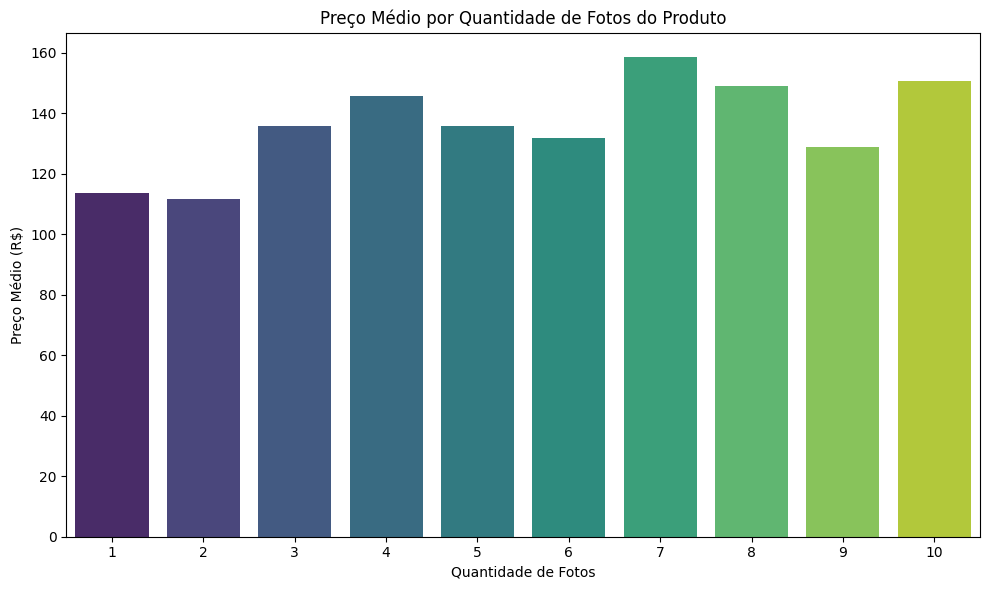

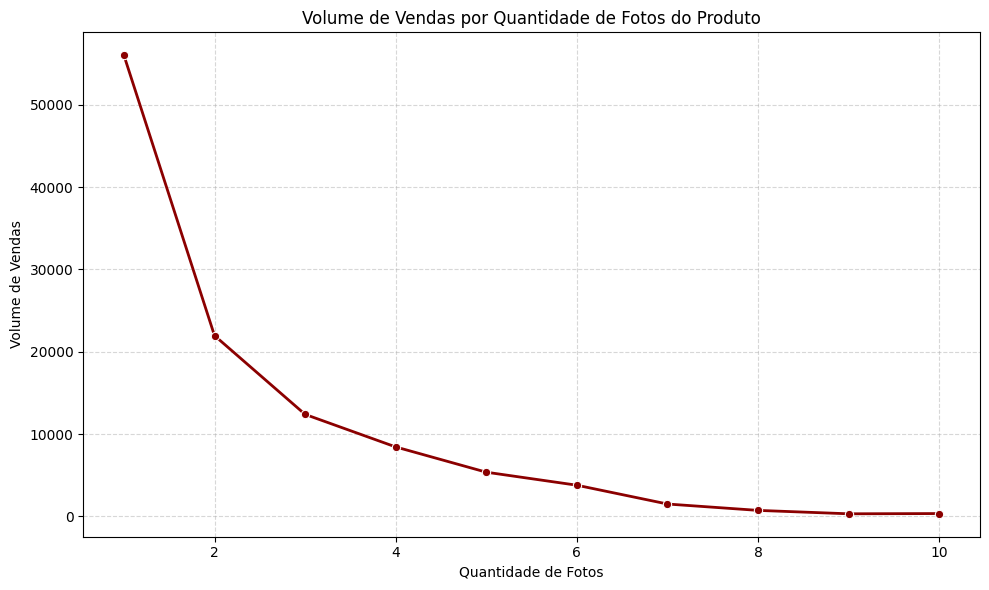

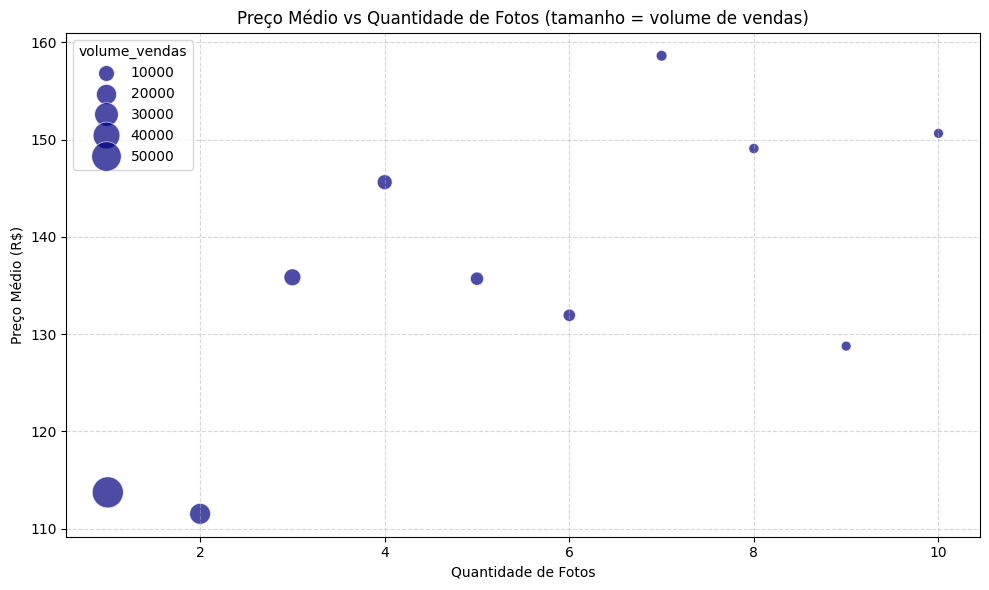


Correlação Fotos × Preço Médio: 0.6576
Correlação Fotos × Volume de Vendas: -0.7823


In [ ]:
# Usando as tabelas já tratadas pelo ETL global (célula anterior) — não recarregar do disco
items = itp.copy()
products = prd.copy()

# Juntar
df = items.merge(products[['product_id', 'product_photos_qty']], on='product_id')

# Remover nulos em product_photos_qty
df = df.dropna(subset=['product_photos_qty'])
df['product_photos_qty'] = df['product_photos_qty'].astype(int)

# Agrupar por quantidade de fotos
analise_fotos = df.groupby('product_photos_qty').agg(
    preco_medio=('price', 'mean'),
    volume_vendas=('order_id', 'count'),
    produtos_distintos=('product_id', 'nunique')
).reset_index()

# Filtrar quantidades de fotos com pelo menos 50 produtos para evitar ruído
analise_fotos = analise_fotos[analise_fotos['produtos_distintos'] >= 50]

print(analise_fotos)

# Plot 1: Preço médio por quantidade de fotos — Seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x='product_photos_qty', y='preco_medio', data=analise_fotos, palette='viridis')
plt.title('Preço Médio por Quantidade de Fotos do Produto')
plt.xlabel('Quantidade de Fotos')
plt.ylabel('Preço Médio (R$)')
plt.tight_layout()
# plt.savefig('/content/q5a.png', dpi=300, bbox_inches='tight') #(imprimir o gráfico)
plt.show()

# Plot 2: Volume de vendas por quantidade de fotos — Seaborn
plt.figure(figsize=(10, 6))
sns.lineplot(x='product_photos_qty', y='volume_vendas', data=analise_fotos, marker='o', color='darkred', linewidth=2)
plt.title('Volume de Vendas por Quantidade de Fotos do Produto')
plt.xlabel('Quantidade de Fotos')
plt.ylabel('Volume de Vendas')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
# plt.savefig('/content/q5b.png', dpi=300, bbox_inches='tight') #(imprimir o gráfico)
plt.show()

# Plot 3: Scatter com tamanho = volume — Seaborn
plt.figure(figsize=(10, 6))
sns.scatterplot(x='product_photos_qty', y='preco_medio', size='volume_vendas',
                data=analise_fotos, color='navy', alpha=0.7, sizes=(50, 500))
plt.title('Preço Médio vs Quantidade de Fotos (tamanho = volume de vendas)')
plt.xlabel('Quantidade de Fotos')
plt.ylabel('Preço Médio (R$)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
# plt.savefig('/content/q5c.png', dpi=300, bbox_inches='tight') #(imprimir o gráfico)
plt.show()

# Correlações com NumPy
corr_preco_fotos = np.corrcoef(analise_fotos['product_photos_qty'].values, analise_fotos['preco_medio'].values)[0, 1]
corr_volume_fotos = np.corrcoef(analise_fotos['product_photos_qty'].values, analise_fotos['volume_vendas'].values)[0, 1]

print(f"\nCorrelação Fotos × Preço Médio: {corr_preco_fotos:.4f}")
print(f"Correlação Fotos × Volume de Vendas: {corr_volume_fotos:.4f}")

---
##### versão em **Matplotlib** puro
---

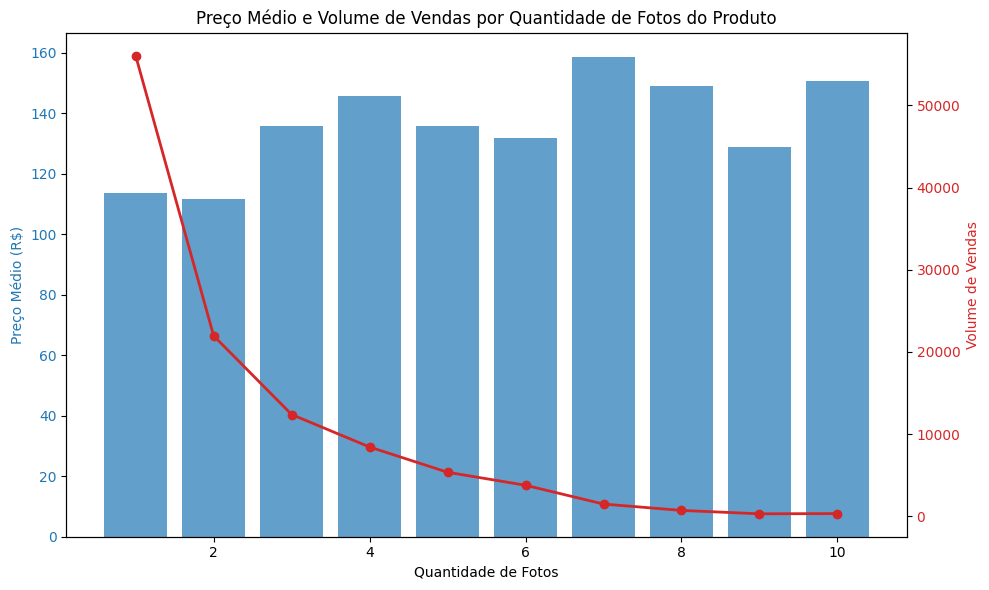

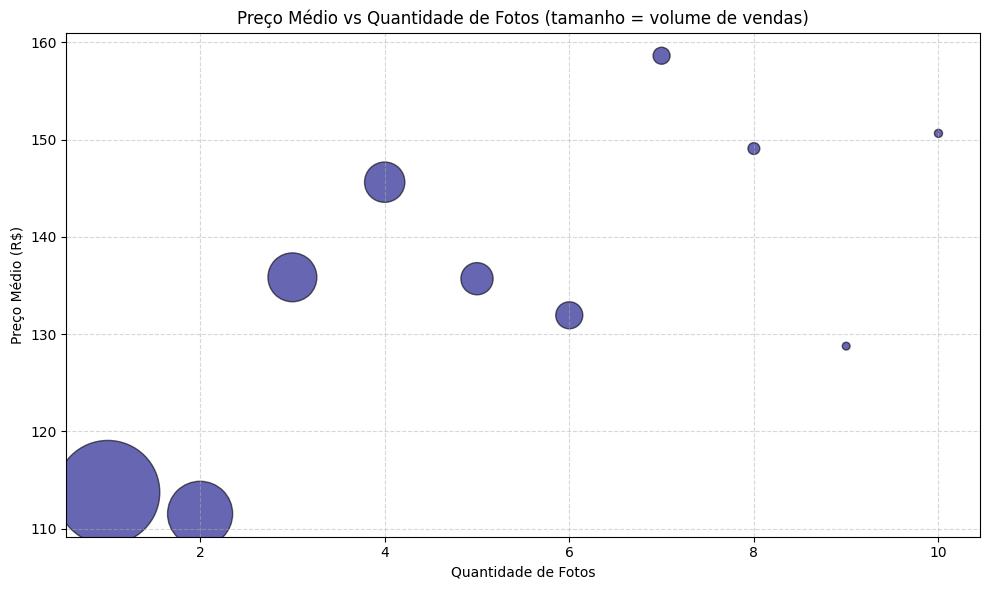

In [ ]:
# Plot 1: Preço médio por quantidade de fotos — Matplotlib puro
fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:blue'
ax1.set_xlabel('Quantidade de Fotos')
ax1.set_ylabel('Preço Médio (R$)', color=color)
ax1.bar(analise_fotos['product_photos_qty'], analise_fotos['preco_medio'], color=color, alpha=0.7, label='Preço Médio')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Volume de Vendas', color=color)
ax2.plot(analise_fotos['product_photos_qty'], analise_fotos['volume_vendas'], color=color, marker='o', linewidth=2, label='Volume de Vendas')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Preço Médio e Volume de Vendas por Quantidade de Fotos do Produto')
fig.tight_layout()
plt.show()

# Plot 2: Scatter com tamanho = volume — Matplotlib puro
plt.figure(figsize=(10, 6))
plt.scatter(analise_fotos['product_photos_qty'], analise_fotos['preco_medio'],
            s=analise_fotos['volume_vendas']/10, c='navy', alpha=0.6, edgecolors='black')
plt.title('Preço Médio vs Quantidade de Fotos (tamanho = volume de vendas)')
plt.xlabel('Quantidade de Fotos')
plt.ylabel('Preço Médio (R$)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Relatório de dados
---

In [ ]:
# ============================================
# RELATÓRIO DE DADOS — Q5: Fotos do Produto × Preço & Volume
# ============================================

print(f"{'='*60}")
print(f"RELATÓRIO DE DADOS — Q5: FOTOS DO PRODUTO × PREÇO & VOLUME")
print(f"{'='*60}")

print(f"\n--- ESCOPO ---")
print(f"Produtos analisados (com fotos cadastradas): {len(df):,}")
print(f"Quantidades de fotos distintas: {analise_fotos['product_photos_qty'].nunique()}")
print(f"Faixa de fotos: {analise_fotos['product_photos_qty'].min()} a {analise_fotos['product_photos_qty'].max()}")
print(f"Filtro aplicado: ≥50 produtos por quantidade de fotos")

print(f"\n--- DISTRIBUIÇÃO DE PRODUTOS POR QUANTIDADE DE FOTOS ---")
for _, row in analise_fotos.iterrows():
    pct_produtos = (row['produtos_distintos'] / analise_fotos['produtos_distintos'].sum()) * 100
    pct_vendas = (row['volume_vendas'] / analise_fotos['volume_vendas'].sum()) * 100
    print(f"  {int(row['product_photos_qty']):2d} foto(s) | {int(row['produtos_distintos']):>6,} produtos ({pct_produtos:5.2f}%) | {int(row['volume_vendas']):>6,} vendas ({pct_vendas:5.2f}%) | R$ {row['preco_medio']:>7.2f} preço médio")

print(f"\n--- CORRELAÇÕES ---")
print(f"Fotos × Preço Médio:    {corr_preco_fotos:+.4f} ({'positiva' if corr_preco_fotos > 0 else 'negativa'}, {'forte' if abs(corr_preco_fotos) > 0.7 else 'moderada' if abs(corr_preco_fotos) > 0.3 else 'fraca'})")
print(f"Fotos × Volume Vendas:  {corr_volume_fotos:+.4f} ({'positiva' if corr_volume_fotos > 0 else 'negativa'}, {'forte' if abs(corr_volume_fotos) > 0.7 else 'moderada' if abs(corr_volume_fotos) > 0.3 else 'fraca'})")

print(f"\n--- CONCENTRAÇÃO DE VOLUME ---")
vol_1_foto = analise_fotos[analise_fotos['product_photos_qty'] == 1]['volume_vendas'].sum()
vol_total = analise_fotos['volume_vendas'].sum()
vol_2_3_fotos = analise_fotos[analise_fotos['product_photos_qty'].isin([2, 3])]['volume_vendas'].sum()
print(f"Vendas com 1 foto:     {int(vol_1_foto):,} ({(vol_1_foto / vol_total) * 100:.1f}%)")
print(f"Vendas com 2-3 fotos:  {int(vol_2_3_fotos):,} ({(vol_2_3_fotos / vol_total) * 100:.1f}%)")
print(f"Vendas com 4+ fotos:   {int(vol_total - vol_1_foto - vol_2_3_fotos):,} ({((vol_total - vol_1_foto - vol_2_3_fotos) / vol_total) * 100:.1f}%)")

print(f"\n--- PREÇO MÉDIO POR FAIXA DE FOTOS ---")
preco_1_foto = analise_fotos[analise_fotos['product_photos_qty'] == 1]['preco_medio'].values[0]
preco_3_mais = analise_fotos[analise_fotos['product_photos_qty'] >= 3]['preco_medio'].mean()
print(f"1 foto:          R$ {preco_1_foto:>7.2f}")
print(f"Média 3+ fotos:  R$ {preco_3_mais:>7.2f}")
print(f"Diferença:       R$ {preco_3_mais - preco_1_foto:>+7.2f} ({((preco_3_mais - preco_1_foto) / preco_1_foto) * 100:+.1f}%)")

print(f"\n--- PREÇO MÁXIMO E MÍNIMO ---")
idx_max = analise_fotos['preco_medio'].idxmax()
idx_min = analise_fotos['preco_medio'].idxmin()
print(f"Maior preço médio:  {analise_fotos.loc[idx_max, 'product_photos_qty']} fotos | R$ {analise_fotos.loc[idx_max, 'preco_medio']:.2f}")
print(f"Menor preço médio:  {analise_fotos.loc[idx_min, 'product_photos_qty']} fotos | R$ {analise_fotos.loc[idx_min, 'preco_medio']:.2f}")

print(f"\n--- PRODUTOS SEM FOTOS (EXCLUÍDOS DO ESCOPO) ---")
produtos_sem_foto = len(items.merge(products[['product_id', 'product_photos_qty']], on='product_id').dropna(subset=['product_photos_qty']) == False)
# Alternativa: calcular do df original antes do dropna
total_produtos_com_foto_info = len(items.merge(products[['product_id', 'product_photos_qty']], on='product_id'))
produtos_com_foto = len(df)
produtos_sem_foto = total_produtos_com_foto_info - produtos_com_foto
print(f"Produtos com info de fotos: {total_produtos_com_foto_info:,}")
print(f"Produtos com fotos (>0):    {produtos_com_foto:,}")
print(f"Produtos sem fotos (NaN):   {produtos_sem_foto:,} ({(produtos_sem_foto / total_produtos_com_foto_info) * 100:.1f}%)")

print(f"{'='*60}")

RELATÓRIO DE DADOS — Q5: FOTOS DO PRODUTO × PREÇO & VOLUME

--- ESCOPO ---
Produtos analisados (com fotos cadastradas): 112,650
Quantidades de fotos distintas: 10
Faixa de fotos: 1 a 10
Filtro aplicado: ≥50 produtos por quantidade de fotos

--- DISTRIBUIÇÃO DE PRODUTOS POR QUANTIDADE DE FOTOS ---
   1 foto(s) | 16,489 produtos (51.17%) | 56,028 vendas (50.54%) | R$  113.72 preço médio
   2 foto(s) |  6,263 produtos (19.43%) | 21,963 vendas (19.81%) | R$  111.52 preço médio
   3 foto(s) |  3,860 produtos (11.98%) | 12,392 vendas (11.18%) | R$  135.83 preço médio
   4 foto(s) |  2,428 produtos ( 7.53%) |  8,437 vendas ( 7.61%) | R$  145.62 preço médio
   5 foto(s) |  1,484 produtos ( 4.60%) |  5,368 vendas ( 4.84%) | R$  135.69 preço médio
   6 foto(s) |    968 produtos ( 3.00%) |  3,786 vendas ( 3.42%) | R$  131.93 preço médio
   7 foto(s) |    343 produtos ( 1.06%) |  1,501 vendas ( 1.35%) | R$  158.62 preço médio
   8 foto(s) |    192 produtos ( 0.60%) |    727 vendas ( 0.66%) | R$  1

---

## 6. Qual a distribuição de itens por pedido?

**Tipo de Análise:** Descritiva  
**Técnicas:** Histograma, estatísticas de cauda longa

**Visualização**  
Histograma com bins unitários e linha de média. A forma assimétrica positiva com moda em 1 revela a predominância de pedidos unitários e a cauda longa de compras múltiplas.

**Justificativa / Apoio à Decisão**  
A forma assimétrica positiva com moda em 1 revela a predominância de pedidos unitários e a cauda longa de compras múltiplas. Quantifica o gap de cross-selling na plataforma e estima o potencial de aumento de ticket médio via mecanismos de recomendação no checkout.

---



 
-------------------------------------
Total de pedidos entregues analisados: 96478
Pedidos com apenas 1 item: 86843 (90.0%)
Média de itens por pedido: 1.14
Mediana de itens por pedido: 1.0
-------------------------------------
 
 


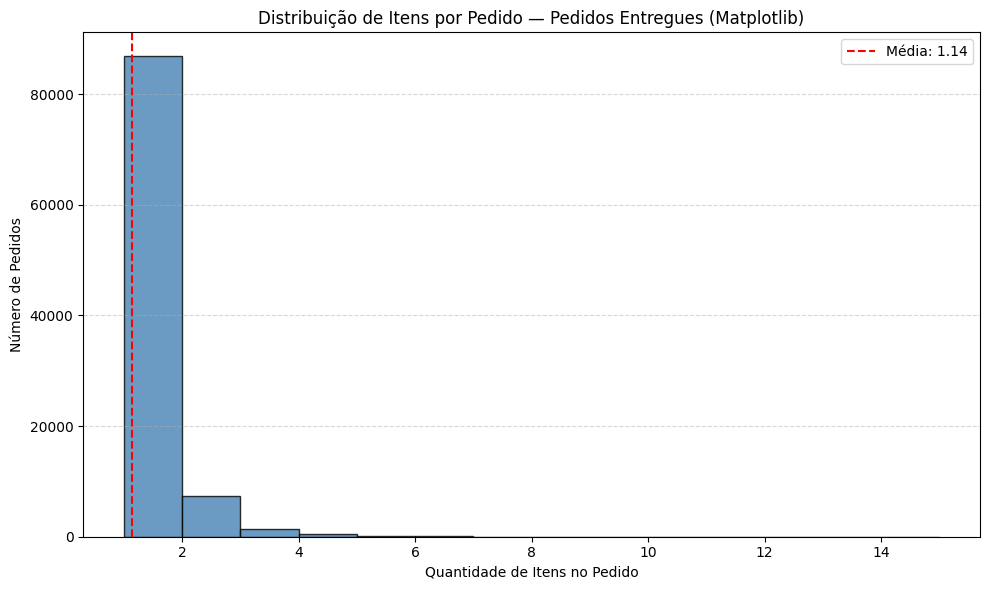

In [ ]:
# 1. Filtrar apenas pedidos entregues (usando variáveis ZEN)
itens_pedido = itp.merge(ped[['order_id', 'order_status']], on='order_id')
itens_pedido = itens_pedido[itens_pedido['order_status'] == 'delivered']

# 2. Contar quantos itens cada pedido tem
qtd_itens_por_pedido = itens_pedido.groupby('order_id').size().reset_index(name='qtd_itens')

# 3. Estatísticas descritivas
total_pedidos = len(qtd_itens_por_pedido)
pedidos_1_item = (qtd_itens_por_pedido['qtd_itens'] == 1).sum()
percentual_1_item = (pedidos_1_item / total_pedidos) * 100

print('\n \n-------------------------------------')
print(f"Total de pedidos entregues analisados: {total_pedidos}")
print(f"Pedidos com apenas 1 item: {pedidos_1_item} ({percentual_1_item:.1f}%)")
print(f"Média de itens por pedido: {qtd_itens_por_pedido['qtd_itens'].mean():.2f}")
print(f"Mediana de itens por pedido: {qtd_itens_por_pedido['qtd_itens'].median():.1f}")
print('-------------------------------------\n \n ')

# 4. Plot — Matplotlib puro
plt.figure(figsize=(10, 6))
plt.hist(qtd_itens_por_pedido['qtd_itens'], bins=range(1, 16),
         color='steelblue', edgecolor='black', alpha=0.8)
plt.title('Distribuição de Itens por Pedido — Pedidos Entregues (Matplotlib)')
plt.xlabel('Quantidade de Itens no Pedido')
plt.ylabel('Número de Pedidos')
plt.axvline(qtd_itens_por_pedido['qtd_itens'].mean(), color='red',
            linestyle='--', label=f'Média: {qtd_itens_por_pedido["qtd_itens"].mean():.2f}')
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
# plt.savefig('/content/q6.png', dpi=300, bbox_inches='tight') #(imprimir o gráfico)
plt.show()


---
### Rerlatório de dados
---

In [ ]:
# ============================================
# RELATÓRIO DE DADOS — Q6: Distribuição de Itens por Pedido
# ============================================

print(f"{'='*60}")
print(f"RELATÓRIO DE DADOS — Q6: DISTRIBUIÇÃO DE ITENS POR PEDIDO")
print(f"{'='*60}")

print(f"\n--- ESCOPO ---")
print(f"Pedidos entregues analisados: {total_pedidos:,}")
print(f"Itens totais no escopo: {itens_pedido['order_item_id'].count():,}" if 'order_item_id' in itens_pedido.columns else f"Itens totais no escopo: {len(itens_pedido):,}")
print(f"Status: delivered")

print(f"\n--- DISTRIBUIÇÃO CENTRAL ---")
print(f"Média de itens por pedido: {qtd_itens_por_pedido['qtd_itens'].mean():.2f}")
print(f"Mediana de itens por pedido: {qtd_itens_por_pedido['qtd_itens'].median():.1f}")
print(f"Desvio padrão: {qtd_itens_por_pedido['qtd_itens'].std():.2f}")
print(f"Máximo de itens em um pedido: {qtd_itens_por_pedido['qtd_itens'].max()}")
print(f"Moda (valor mais frequente): {qtd_itens_por_pedido['qtd_itens'].mode().values[0]}")

print(f"\n--- CONCENTRAÇÃO ---")
print(f"Pedidos com 1 item:  {pedidos_1_item:>6,} ({percentual_1_item:5.1f}%)")
for qtd in [2, 3, 4, 5]:
    pedidos_qtd = (qtd_itens_por_pedido['qtd_itens'] == qtd).sum()
    pct = (pedidos_qtd / total_pedidos) * 100
    print(f"Pedidos com {qtd} itens: {pedidos_qtd:>6,} ({pct:5.1f}%)")

print(f"\n--- CAUDA LONGA (6+ ITENS) ---")
pedidos_6mais = (qtd_itens_por_pedido['qtd_itens'] >= 6).sum()
pct_6mais = (pedidos_6mais / total_pedidos) * 100
print(f"Pedidos com 6+ itens: {pedidos_6mais:,} ({pct_6mais:.2f}%)")
print(f"Pedidos com 10+ itens: {(qtd_itens_por_pedido['qtd_itens'] >= 10).sum():,}")

print(f"\n--- ACUMULADO ---")
pct_acumulado_1 = percentual_1_item
pct_acumulado_2 = pct_acumulado_1 + ((qtd_itens_por_pedido['qtd_itens'] == 2).sum() / total_pedidos) * 100
pct_acumulado_3 = pct_acumulado_2 + ((qtd_itens_por_pedido['qtd_itens'] == 3).sum() / total_pedidos) * 100
print(f"Até 1 item:  {pct_acumulado_1:5.1f}%")
print(f"Até 2 itens: {pct_acumulado_2:5.1f}%")
print(f"Até 3 itens: {pct_acumulado_3:5.1f}%")

print(f"\n--- OPORTUNIDADE DE CROSS-SELLING ---")
ticket_medio_1_item = itens_pedido.groupby('order_id')['price'].sum().mean()
ticket_2mais = itens_pedido.groupby('order_id')['price'].sum()[qtd_itens_por_pedido[qtd_itens_por_pedido['qtd_itens'] >= 2]['order_id']].mean() if (qtd_itens_por_pedido['qtd_itens'] >= 2).any() else 0
print(f"Ticket médio (1 item):  R$ {ticket_medio_1_item:.2f}")
print(f"Ticket médio (2+ itens): R$ {ticket_2mais:.2f}" if ticket_2mais > 0 else "Ticket médio (2+ itens): sem dados suficientes")

print(f"{'='*60}")

RELATÓRIO DE DADOS — Q6: DISTRIBUIÇÃO DE ITENS POR PEDIDO

--- ESCOPO ---
Pedidos entregues analisados: 96,478
Itens totais no escopo: 110,197
Status: delivered

--- DISTRIBUIÇÃO CENTRAL ---
Média de itens por pedido: 1.14
Mediana de itens por pedido: 1.0
Desvio padrão: 0.54
Máximo de itens em um pedido: 21
Moda (valor mais frequente): 1

--- CONCENTRAÇÃO ---
Pedidos com 1 item:  86,843 ( 90.0%)
Pedidos com 2 itens:  7,392 (  7.7%)
Pedidos com 3 itens:  1,306 (  1.4%)
Pedidos com 4 itens:    495 (  0.5%)
Pedidos com 5 itens:    193 (  0.2%)

--- CAUDA LONGA (6+ ITENS) ---
Pedidos com 6+ itens: 249 (0.26%)
Pedidos com 10+ itens: 25

--- ACUMULADO ---
Até 1 item:   90.0%
Até 2 itens:  97.7%
Até 3 itens:  99.0%

--- OPORTUNIDADE DE CROSS-SELLING ---
Ticket médio (1 item):  R$ 137.04
Ticket médio (2+ itens): R$ 203.21


---

## 7. É possível prever insatisfação do cliente antes da avaliação ser publicada?

**Tipo de Análise:** Preditiva  
**Técnicas:** Random Forest, Logistic Regression, matriz de confusão

**Visualização**  
Barras horizontais para importância de features no modelo Random Forest, e heatmap para matriz de confusão. A primeira revela quais variáveis operacionais explicam a insatisfação; a segunda quantifica o erro do modelo (falsos positivos/negativos).

**Justificativa / Apoio à Decisão**  
Random Forest captura relações não-lineares entre variáveis operacionais (tempo de entrega, frete, parcelas) e insatisfação. A matriz de confusão quantifica o erro do modelo, avaliando se a precisão é suficiente para operacionalização como sistema de alerta preemptivo.

---


=== REGRESSÃO LOGÍSTICA ===
              precision    recall  f1-score   support

  Satisfeito       0.92      0.78      0.85     20890
Insatisfeito       0.27      0.57      0.37      3068

    accuracy                           0.75     23958
   macro avg       0.60      0.67      0.61     23958
weighted avg       0.84      0.75      0.78     23958


=== RANDOM FOREST ===
              precision    recall  f1-score   support

  Satisfeito       0.92      0.89      0.90     20890
Insatisfeito       0.39      0.48      0.43      3068

    accuracy                           0.84     23958
   macro avg       0.65      0.69      0.67     23958
weighted avg       0.85      0.84      0.84     23958



/tmp/ipykernel_2839/1911549559.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importancia', y='feature', data=importancias, palette='viridis')


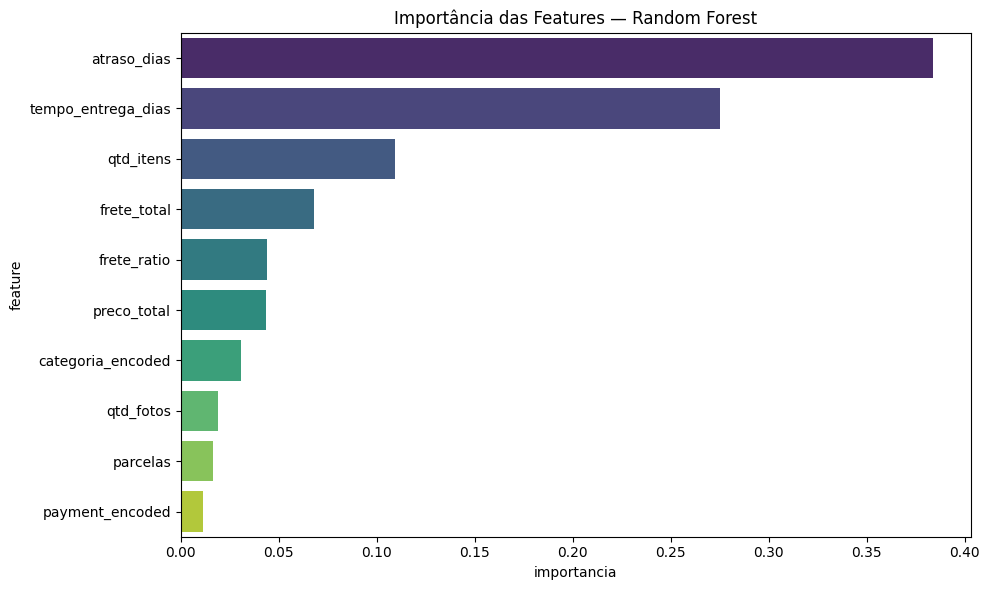

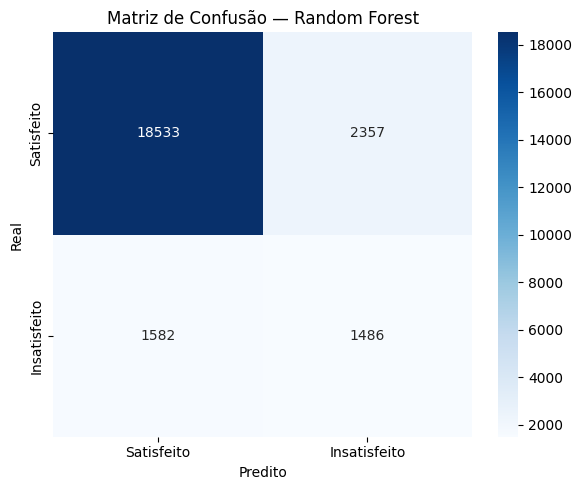


Média da probabilidade de insatisfação: 0.395
Pedidos com risco > 70%: 1410


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 1. Escopo: pedidos entregues com review
ped_entregues = ped[ped['order_delivered_customer_date'].notna()][[
    'order_id', 'customer_id', 'order_purchase_timestamp',
    'order_delivered_customer_date', 'order_estimated_delivery_date'
]]
reviews_ped = avl.merge(ped_entregues, on='order_id')

# 2. Features temporais
reviews_ped['tempo_entrega_dias'] = (
    reviews_ped['order_delivered_customer_date'] - reviews_ped['order_purchase_timestamp']
).dt.days
reviews_ped['atraso_dias'] = (
    reviews_ped['order_delivered_customer_date'] - reviews_ped['order_estimated_delivery_date']
).dt.days

# 3. Joins com itens, produtos e pagamentos
reviews_itens = reviews_ped.merge(itp[['order_id', 'price', 'freight_value', 'product_id']], on='order_id')
reviews_prod = reviews_itens.merge(prd[['product_id', 'product_photos_qty', 'product_category_name']], on='product_id', how='left')
reviews_pag = reviews_prod.merge(pgpd[['order_id', 'payment_installments', 'payment_type']], on='order_id', how='left')

# 4. Agregar por pedido
agg_features = reviews_pag.groupby('order_id').agg(
    review_score=('review_score', 'first'),
    tempo_entrega_dias=('tempo_entrega_dias', 'first'),
    atraso_dias=('atraso_dias', 'first'),
    preco_total=('price', 'sum'),
    frete_total=('freight_value', 'sum'),
    qtd_itens=('product_id', 'count'),
    qtd_fotos=('product_photos_qty', 'mean'),
    parcelas=('payment_installments', 'first'),
    payment_type=('payment_type', 'first'),
    categoria=('product_category_name', 'first')
).reset_index()

# 5. Target e feature engineering
agg_features['insatisfeito'] = (agg_features['review_score'] <= 2).astype(int)
agg_features['frete_ratio'] = agg_features['frete_total'] / agg_features['preco_total']
agg_features['frete_ratio'] = agg_features['frete_ratio'].replace([np.inf, -np.inf], np.nan).fillna(0)
agg_features['parcelas'] = agg_features['parcelas'].fillna(1)
agg_features['payment_type'] = agg_features['payment_type'].fillna('desconhecido')

# Encoding
le_cat = LabelEncoder()
le_pay = LabelEncoder()
agg_features['categoria_encoded'] = le_cat.fit_transform(agg_features['categoria'])
agg_features['payment_encoded'] = le_pay.fit_transform(agg_features['payment_type'])

# 6. Dataset de modelagem
features = ['tempo_entrega_dias', 'atraso_dias', 'preco_total', 'frete_total',
            'frete_ratio', 'qtd_itens', 'qtd_fotos', 'parcelas',
            'categoria_encoded', 'payment_encoded']
X = agg_features[features]
y = agg_features['insatisfeito']

# 7. Split e normalização
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 8. Regressão Logística
modelo_lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
modelo_lr.fit(X_train_scaled, y_train)
y_pred_lr = modelo_lr.predict(X_test_scaled)

print("=== REGRESSÃO LOGÍSTICA ===")
print(classification_report(y_test, y_pred_lr, target_names=['Satisfeito', 'Insatisfeito']))

# 9. Random Forest
modelo_rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, max_depth=10)
modelo_rf.fit(X_train, y_train)
y_pred_rf = modelo_rf.predict(X_test)

print("\n=== RANDOM FOREST ===")
print(classification_report(y_test, y_pred_rf, target_names=['Satisfeito', 'Insatisfeito']))

# 10. Importância das features
importancias = pd.DataFrame({
    'feature': features,
    'importancia': modelo_rf.feature_importances_
}).sort_values('importancia', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='importancia', y='feature', data=importancias, palette='viridis')
plt.title('Importância das Features — Random Forest')
plt.tight_layout()
# plt.savefig('/content/q7a.png', dpi=300, bbox_inches='tight') #(imprimir o gráfico)
plt.show()

# 11. Matriz de confusão
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Satisfeito', 'Insatisfeito'],
            yticklabels=['Satisfeito', 'Insatisfeito'])
plt.title('Matriz de Confusão — Random Forest')
plt.ylabel('Real')
plt.xlabel('Predito')
plt.tight_layout()
# plt.savefig('/content/q7b.png', dpi=300, bbox_inches='tight') #(imprimir o gráfico)
plt.show()

# 12. Probabilidade de risco
prob_insatisfacao = modelo_rf.predict_proba(X_test)[:, 1]
print(f"\nMédia da probabilidade de insatisfação: {prob_insatisfacao.mean():.3f}")
print(f"Pedidos com risco > 70%: {(prob_insatisfacao > 0.70).sum()}")

---
### Relatório de dados
---

In [ ]:
# ============================================
# RELATÓRIO DE DADOS — Q7: Prever Insatisfação do Cliente
# ============================================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Métricas calculadas dos outputs
acc_lr = accuracy_score(y_test, y_pred_lr)
acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print(f"{'='*60}")
print(f"RELATÓRIO DE DADOS — Q7: PREVER INSATISFAÇÃO DO CLIENTE")
print(f"{'='*60}")

print(f"\n--- ESCOPO ---")
print(f"Registros no escopo: {len(agg_features):,}")
print(f"Features utilizadas: {len(features)}")
print(f"Target: insatisfeito = review_score ≤ 2")
print(f"Class balance: {y.value_counts()[0]:,} satisfeitos | {y.value_counts()[1]:,} insatisfeitos")

print(f"\n--- SPLIT ---")
print(f"Treino: {len(X_train):,} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Teste:  {len(X_test):,} ({len(X_test)/len(X)*100:.1f}%)")
print(f"Estratificado: sim (random_state=42)")

print(f"\n--- MODELO: REGRESSÃO LOGÍSTICA ---")
print(f"Acurácia:  {acc_lr:.4f} ({acc_lr*100:.2f}%)")
print(f"Precision (insatisfeito): {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall (insatisfeito):    {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1-score (insatisfeito):  {f1_score(y_test, y_pred_lr):.4f}")

print(f"\n--- MODELO: RANDOM FOREST ---")
print(f"Acurácia:  {acc_rf:.4f} ({acc_rf*100:.2f}%)")
print(f"Precision (insatisfeito): {prec_rf:.4f}")
print(f"Recall (insatisfeito):    {rec_rf:.4f}")
print(f"F1-score (insatisfeito):  {f1_rf:.4f}")

print(f"\n--- IMPORTÂNCIA DAS FEATURES (RANDOM FOREST) ---")
for i, row in importancias.iterrows():
    bar = '█' * int(row['importancia'] * 50)
    print(f"  {row['feature']:25s} | {row['importancia']:.4f} | {bar}")

print(f"\n--- MATRIZ DE CONFUSÃO (RANDOM FOREST) ---")
tn, fp, fn, tp = cm.ravel()
print(f"  Verdadeiro Negativo (Satisfeito → Satisfeito): {tn:,}")
print(f"  Falso Positivo    (Satisfeito → Insatisfeito): {fp:,}")
print(f"  Falso Negativo    (Insatisfeito → Satisfeito): {fn:,}")
print(f"  Verdadeiro Positivo (Insatisfeito → Insatisfeito): {tp:,}")
print(f"  Sensibilidade (recall): {tp/(tp+fn):.4f}")
print(f"  Especificidade:         {tn/(tn+fp):.4f}")

print(f"\n--- PROBABILIDADE DE RISCO ---")
print(f"Média da probabilidade de insatisfação: {prob_insatisfacao.mean():.4f}")
print(f"Pedidos com risco > 50%: {(prob_insatisfacao > 0.50).sum():,}")
print(f"Pedidos com risco > 70%: {(prob_insatisfacao > 0.70).sum():,}")
print(f"Pedidos com risco > 90%: {(prob_insatisfacao > 0.90).sum():,}")
pct_risco_alto = ((prob_insatisfacao > 0.70).sum() / len(prob_insatisfacao)) * 100
print(f"% do teste com risco > 70%: {pct_risco_alto:.2f}%")

print(f"\n--- COMPARAÇÃO DE MODELOS ---")
print(f"{'Métrica':<20} | {'Logística':>10} | {'Random Forest':>13}")
print(f"{'-'*50}")
print(f"{'Acurácia':<20} | {acc_lr:>10.4f} | {acc_rf:>13.4f}")
print(f"{'Precision':<20} | {precision_score(y_test, y_pred_lr):>10.4f} | {prec_rf:>13.4f}")
print(f"{'Recall':<20} | {recall_score(y_test, y_pred_lr):>10.4f} | {rec_rf:>13.4f}")
print(f"{'F1-score':<20} | {f1_score(y_test, y_pred_lr):>10.4f} | {f1_rf:>13.4f}")

print(f"{'='*60}")

RELATÓRIO DE DADOS — Q7: PREVER INSATISFAÇÃO DO CLIENTE

--- ESCOPO ---
Registros no escopo: 95,830
Features utilizadas: 10
Target: insatisfeito = review_score ≤ 2
Class balance: 83,560 satisfeitos | 12,270 insatisfeitos

--- SPLIT ---
Treino: 71,872 (75.0%)
Teste:  23,958 (25.0%)
Estratificado: sim (random_state=42)

--- MODELO: REGRESSÃO LOGÍSTICA ---
Acurácia:  0.7519 (75.19%)
Precision (insatisfeito): 0.2744
Recall (insatisfeito):    0.5701
F1-score (insatisfeito):  0.3704

--- MODELO: RANDOM FOREST ---
Acurácia:  0.8356 (83.56%)
Precision (insatisfeito): 0.3867
Recall (insatisfeito):    0.4844
F1-score (insatisfeito):  0.4300

--- IMPORTÂNCIA DAS FEATURES (RANDOM FOREST) ---
  atraso_dias               | 0.3839 | ███████████████████
  tempo_entrega_dias        | 0.2750 | █████████████
  qtd_itens                 | 0.1091 | █████
  frete_total               | 0.0680 | ███
  frete_ratio               | 0.0438 | ██
  preco_total               | 0.0432 | ██
  categoria_encoded        

---

## 8. Qual ação operacional deve ser tomada para sellers com alto volume de avaliações negativas e frete desproporcional?

**Tipo de Análise:** Prescritiva  
**Técnicas:** Regras de negócio, matriz de intervenção, quadrantes

**Visualização**  
Barras horizontais para distribuição de ações prescritivas, e scatter plot com quadrantes delimitados por thresholds de frete ratio e nota média. O scatter permite localizar cada seller em matriz de risco, diferenciando grandes contribuidores de pequenos operadores problemáticos.

**Justificativa / Apoio à Decisão**  
A matriz de intervenção classifica sellers automaticamente por prioridade (treinamento, suspensão de destaque, offboarding) com base em thresholds de frete desproporcional e nota média. Automatiza decisões operacionais sem análise manual caso a caso.

---


=== MATRIZ DE INTERVENÇÃO PRESCRITIVA ===
acao_prescrita
MONITORAMENTO                                   1552
TREINAMENTO_LOGISTICA                            294
SUSPENSAO_TEMPORARIA_DESTAQUE                     36
TREINAMENTO_OBRIGATORIO + SUSPENSAO_DESTAQUE      29
Name: count, dtype: int64


=== TOP 10 SELLERS COM INTERVENÇÃO ATIVA ===


,seller_id,seller_city,seller_state,bad_reviews,nota_media,avg_frete_ratio,total_orders,acao_prescrita
938,7c67e1448b00f6e969d365cea6b010ab,itaquaquecetuba,SP,402,3.348208,0.311791,253,TREINAMENTO_LOGISTICA
231,1f50f920176fa81dab994f9023523100,sao jose do rio preto,SP,351,3.982402,0.352598,198,TREINAMENTO_LOGISTICA
116,1025f0e2d44d7041d6cf58b6550e0bfa,sao paulo,SP,294,3.849755,0.336968,159,TREINAMENTO_LOGISTICA
1745,ea8482cd71df3c1969d7b9473ff13abc,sao paulo,SP,199,3.953216,0.501935,176,TREINAMENTO_LOGISTICA
1051,8b321bb669392f5163d04c59e235e066,sao paulo,SP,174,3.995069,0.985969,141,TREINAMENTO_LOGISTICA
1571,d2374cbcbb3ca4ab1086534108cc3ab7,ibitinga,SP,159,3.636364,0.491670,108,TREINAMENTO_LOGISTICA
174,1835b56ce799e6a4dc4eddc053f04066,ibitinga,SP,143,3.593863,0.364373,104,TREINAMENTO_LOGISTICA
1033,897060da8b9a21f655304d50fd935913,ribeirao preto,SP,136,3.395349,0.515740,82,TREINAMENTO_LOGISTICA
343,2eb70248d66e0e3ef83659f71b244378,campinas,SP,105,2.712919,0.106878,100,SUSPENSAO_TEMPORARIA_DESTAQUE
411,391fc6631aebcf3004804e51b40bcf1e,ibitinga,SP,103,3.953376,0.313705,81,TREINAMENTO_LOGISTICA


/tmp/ipykernel_2839/741533761.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='qtd_sellers', y='acao', data=acao_counts, palette='rocket')


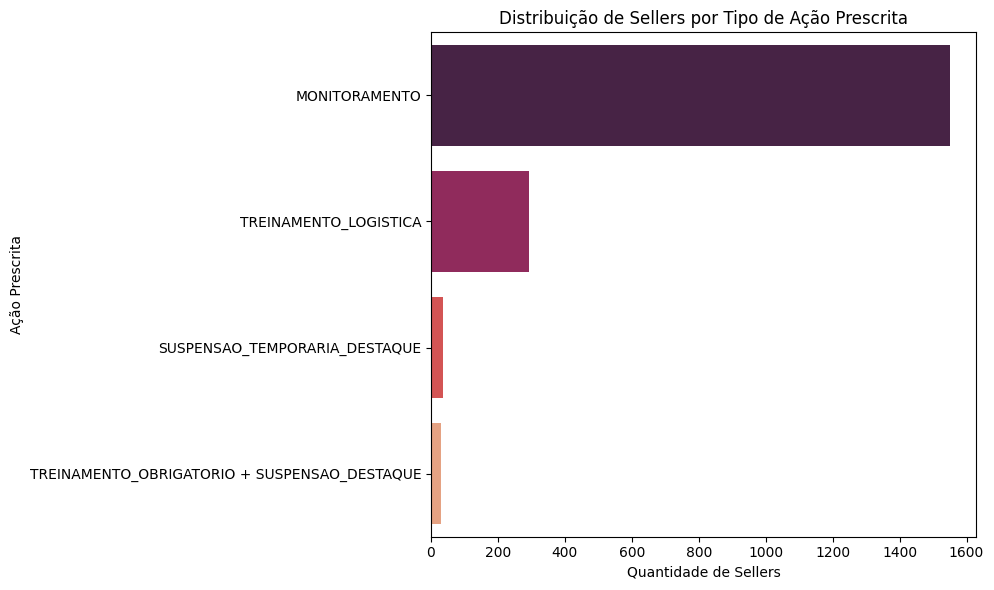

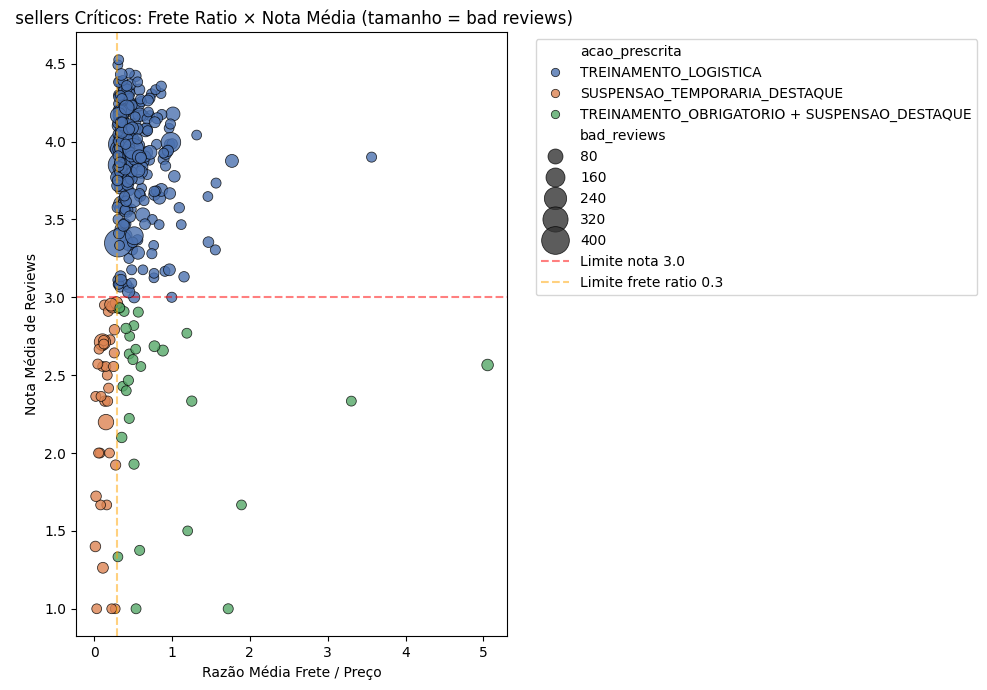

In [ ]:
# 1. Filtrar avaliações negativas (nota 1 ou 2)
reviews_neg = avl[avl['review_score'].isin([1, 2])]

# 2. Juntar com items para associar ao seller_id
seller_reviews = reviews_neg.merge(itp[['order_id', 'seller_id', 'price', 'freight_value']],
                                    on='order_id', how='inner')

# 3. Agregar métricas por seller
seller_metrics = seller_reviews.groupby('seller_id').agg(
    bad_reviews=('review_score', 'count'),
    avg_frete_ratio=('freight_value', lambda x: (x / seller_reviews.loc[x.index, 'price']).mean()),
    avg_price=('price', 'mean'),
    total_orders=('order_id', 'nunique')
).reset_index()

# 4. Juntar com nota média geral (incluindo reviews positivas)
all_reviews = avl.merge(itp[['order_id', 'seller_id']], on='order_id', how='inner')
nota_media = all_reviews.groupby('seller_id')['review_score'].mean().reset_index(name='nota_media')
seller_metrics = seller_metrics.merge(nota_media, on='seller_id', how='left')

# 5. Juntar com dados do seller (cidade/estado) — opcional, mas enriquece
seller_metrics = seller_metrics.merge(vndd[['seller_id', 'seller_city', 'seller_state']],
                                       on='seller_id', how='left')

# 6. Limpar frete_ratio
seller_metrics['avg_frete_ratio'] = seller_metrics['avg_frete_ratio'].replace([np.inf, -np.inf], np.nan)
seller_metrics['avg_frete_ratio'] = seller_metrics['avg_frete_ratio'].fillna(0)

# 7. Definir regras prescritivas
# Critérios de volume mínimo para não penalizar sellers pequenos
VOLUME_MIN = 5

def definir_acao(row):
    if row['bad_reviews'] >= VOLUME_MIN and row['avg_frete_ratio'] > 0.3 and row['nota_media'] < 3.0:
        return 'TREINAMENTO_OBRIGATORIO + SUSPENSAO_DESTAQUE'
    elif row['bad_reviews'] >= VOLUME_MIN and row['avg_frete_ratio'] > 0.3:
        return 'TREINAMENTO_LOGISTICA'
    elif row['bad_reviews'] >= VOLUME_MIN and row['nota_media'] < 3.0:
        return 'SUSPENSAO_TEMPORARIA_DESTAQUE'
    elif row['bad_reviews'] >= 10 and row['avg_price'] < 50 and row['nota_media'] < 2.5:
        return 'OFFBOARDING_SUGERIDO'
    else:
        return 'MONITORAMENTO'

seller_metrics['acao_prescrita'] = seller_metrics.apply(definir_acao, axis=1)

# 8. Resumo da matriz de intervenção
print("=== MATRIZ DE INTERVENÇÃO PRESCRITIVA ===")
print(seller_metrics['acao_prescrita'].value_counts())
print("\n")

# 9. Top sellers críticos (ações mais graves)
criticos = seller_metrics[seller_metrics['acao_prescrita'] != 'MONITORAMENTO'].sort_values(
    'bad_reviews', ascending=False
)

print("=== TOP 10 SELLERS COM INTERVENÇÃO ATIVA ===")
display(criticos[['seller_id', 'seller_city', 'seller_state', 'bad_reviews',
                  'nota_media', 'avg_frete_ratio', 'total_orders', 'acao_prescrita']].head(10))

# 10. Plot — Sellers críticos por tipo de ação
plt.figure(figsize=(10, 6))
acao_counts = seller_metrics['acao_prescrita'].value_counts().reset_index()
acao_counts.columns = ['acao', 'qtd_sellers']
sns.barplot(x='qtd_sellers', y='acao', data=acao_counts, palette='rocket')
plt.title('Distribuição de Sellers por Tipo de Ação Prescrita')
plt.xlabel('Quantidade de Sellers')
plt.ylabel('Ação Prescrita')
plt.tight_layout()
# plt.savefig('/content/q8a.png', dpi=300, bbox_inches='tight') #(imprimir o gráfico)
plt.show()

# 11. Plot — Scatter Frete Ratio vs Nota Média (colorido por ação)
plt.figure(figsize=(10, 7))
scatter_data = seller_metrics[seller_metrics['acao_prescrita'] != 'MONITORAMENTO']
sns.scatterplot(data=scatter_data, x='avg_frete_ratio', y='nota_media',
                hue='acao_prescrita', size='bad_reviews', sizes=(50, 400),
                palette='deep', alpha=0.8, edgecolor='black')
plt.title(' sellers Críticos: Frete Ratio × Nota Média (tamanho = bad reviews)')
plt.xlabel('Razão Média Frete / Preço')
plt.ylabel('Nota Média de Reviews')
plt.axhline(3.0, color='red', linestyle='--', alpha=0.5, label='Limite nota 3.0')
plt.axvline(0.3, color='orange', linestyle='--', alpha=0.5, label='Limite frete ratio 0.3')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
# plt.savefig('/content/q8b.png', dpi=300, bbox_inches='tight') #(imprimir o gráfico)
plt.show()

---
### Relatório de dados
---

In [ ]:
# ============================================
# RELATÓRIO DE DADOS — Q8: Matriz de Intervenção para Sellers Problemáticos
# ============================================

print(f"{'='*60}")
print(f"RELATÓRIO DE DADOS — Q8: MATRIZ DE INTERVENÇÃO PRESCRITIVA")
print(f"{'='*60}")

print(f"\n--- ESCOPO ---")
print(f"Sellers analisados: {len(seller_metrics):,}")
print(f"Reviews negativas no escopo: {reviews_neg['review_score'].count():,}")
print(f"Threshold volume mínimo: {VOLUME_MIN} reviews negativas")
print(f"Threshold frete ratio: 0.30")
print(f"Threshold nota média: 3.0")

print(f"\n--- DISTRIBUIÇÃO DE AÇÕES ---")
for acao, qtd in seller_metrics['acao_prescrita'].value_counts().items():
    pct = (qtd / len(seller_metrics)) * 100
    print(f"  {acao:<45s} | {qtd:>4} sellers ({pct:5.2f}%)")

print(f"\n--- SELLERS COM INTERVENÇÃO ATIVA ---")
ativos = seller_metrics[seller_metrics['acao_prescrita'] != 'MONITORAMENTO']
print(f"Total com ação ativa: {len(ativos):,} ({(len(ativos)/len(seller_metrics))*100:.2f}%)")
print(f"Reviews negativas concentradas neles: {ativos['bad_reviews'].sum():,} ({(ativos['bad_reviews'].sum()/seller_metrics['bad_reviews'].sum())*100:.1f}%)")

print(f"\n--- TOP 10 SELLERS COM INTERVENÇÃO ATIVA ---")
for i, row in criticos.head(10).iterrows():
    print(f"  {i+1:2d}. {row['seller_id'][:8]:8s} | {row['seller_city']:20s} {row['seller_state']:2s} | {int(row['bad_reviews']):>3} bad | nota {row['nota_media']:.2f} | frete {row['avg_frete_ratio']:.2f} | {row['acao_prescrita']}")

print(f"\n--- MÉTRICAS DOS SELLERS CRÍTICOS ---")
print(f"Nota média geral: {seller_metrics['nota_media'].mean():.2f}")
print(f"Nota média dos críticos: {ativos['nota_media'].mean():.2f}")
print(f"Frete ratio médio geral: {seller_metrics['avg_frete_ratio'].mean():.3f}")
print(f"Frete ratio médio dos críticos: {ativos['avg_frete_ratio'].mean():.3f}")
print(f"Preço médio geral: R$ {seller_metrics['avg_price'].mean():.2f}")
print(f"Preço médio dos críticos: R$ {ativos['avg_price'].mean():.2f}")

print(f"\n--- CONCENTRAÇÃO GEOGRÁFICA (CRÍTICOS) ---")
geo_criticos = ativos['seller_state'].value_counts().head(5)
for estado, qtd in geo_criticos.items():
    pct = (qtd / len(ativos)) * 100
    print(f"  {estado}: {qtd} sellers ({pct:.1f}%)")

print(f"\n--- SIMULAÇÃO: APLICAR AÇÕES ---")
offboarding = len(seller_metrics[seller_metrics['acao_prescrita'] == 'OFFBOARDING_SUGERIDO'])
treinamento = len(seller_metrics[seller_metrics['acao_prescrita'].str.contains('TREINAMENTO')])
suspensao = len(seller_metrics[seller_metrics['acao_prescrita'].str.contains('SUSPENSAO')])
print(f"Offboarding sugerido: {offboarding} sellers")
print(f"Treinamento (qualquer tipo): {treinamento} sellers")
print(f"Suspensão (qualquer tipo): {suspensao} sellers")

print(f"{'='*60}")

RELATÓRIO DE DADOS — Q8: MATRIZ DE INTERVENÇÃO PRESCRITIVA

--- ESCOPO ---
Sellers analisados: 1,911
Reviews negativas no escopo: 14,575
Threshold volume mínimo: 5 reviews negativas
Threshold frete ratio: 0.30
Threshold nota média: 3.0

--- DISTRIBUIÇÃO DE AÇÕES ---
  MONITORAMENTO                                 | 1552 sellers (81.21%)
  TREINAMENTO_LOGISTICA                         |  294 sellers (15.38%)
  SUSPENSAO_TEMPORARIA_DESTAQUE                 |   36 sellers ( 1.88%)
  TREINAMENTO_OBRIGATORIO + SUSPENSAO_DESTAQUE  |   29 sellers ( 1.52%)

--- SELLERS COM INTERVENÇÃO ATIVA ---
Total com ação ativa: 359 (18.79%)
Reviews negativas concentradas neles: 8,172 (45.1%)

--- TOP 10 SELLERS COM INTERVENÇÃO ATIVA ---
  939. 7c67e144 | itaquaquecetuba      SP | 402 bad | nota 3.35 | frete 0.31 | TREINAMENTO_LOGISTICA
  232. 1f50f920 | sao jose do rio preto SP | 351 bad | nota 3.98 | frete 0.35 | TREINAMENTO_LOGISTICA
  117. 1025f0e2 | sao paulo            SP | 294 bad | nota 3.85 | fret

---

## 9. Quanto da receita da plataforma está concentrada em sellers tóxicos?

**Tipo de Análise:** Prescritiva  
**Técnicas:** Scatter log, quadrantes risco-receita, Pareto

**Visualização**  
Scatter plot em escala logarítmica com quadrantes coloridos por risco-receita, e barras para distribuição de sellers por quadrante. A escala log acomoda a cauda longa da receita; os quadrantes separam players estratégicos de descartáveis.

**Justificativa / Apoio à Decisão**  
A escala log acomoda a cauda longa da receita; os quadrantes separam players estratégicos de descartáveis. Quantifica o impacto financeiro de intervenções punitivas, evitando decisões que comprometam o P&L da plataforma.

---


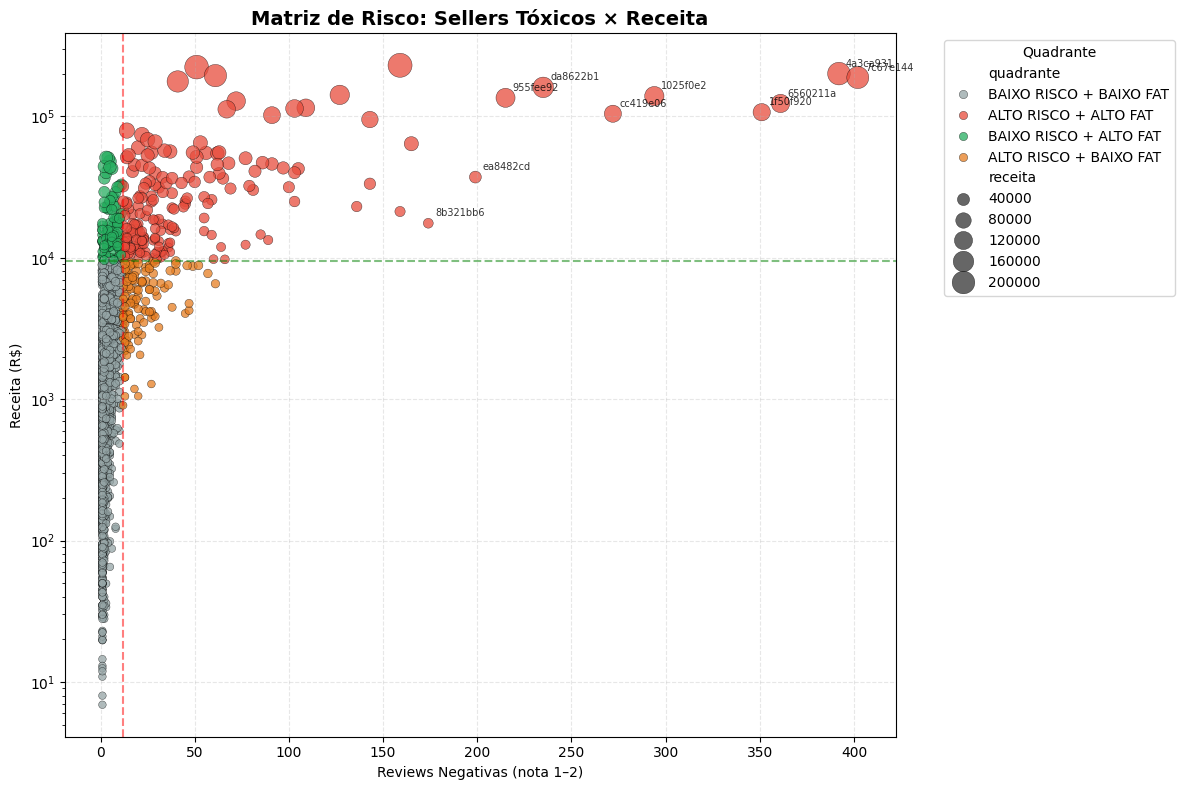

/tmp/ipykernel_2839/3878410759.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='qtd', y='quadrante', data=acao_counts, palette=[palette_quad[q] for q in acao_counts['quadrante']])


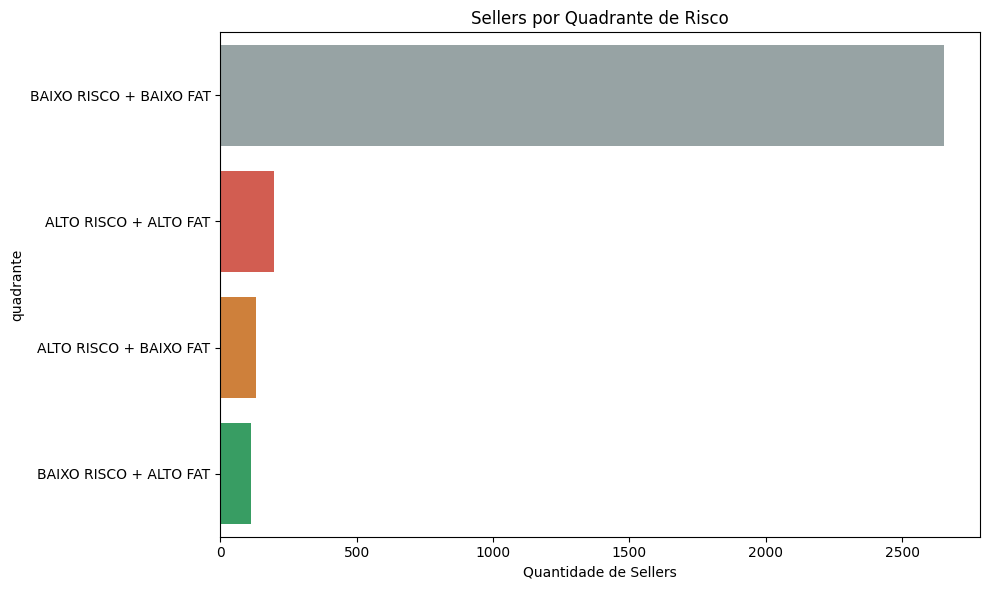

In [ ]:
# ==============================================================================
# Q9 — Concentração de Risco: Vendedores Tóxicos vs. Receita
# ==============================================================================

# 1. Receita total
receita_total = itp['price'].sum()

# 2. Reviews negativas por vendedor
reviews_neg = avl[avl['review_score'].isin([1, 2])]
reviews_seller = reviews_neg.merge(itp[['order_id', 'seller_id']], on='order_id', how='inner')
seller_bad_reviews = reviews_seller.groupby('seller_id').size().reset_index(name='bad_reviews')

# 3. Receita por seller
receita_por_seller = itp.groupby('seller_id')['price'].sum().reset_index(name='receita')

# 4. Base unificada
seller_risco = seller_bad_reviews.merge(receita_por_seller, on='seller_id', how='outer')
seller_risco['bad_reviews'] = seller_risco['bad_reviews'].fillna(0).astype(int)
seller_risco['receita'] = seller_risco['receita'].fillna(0)
seller_risco['pct_receita_plataforma'] = (seller_risco['receita'] / receita_total) * 100
seller_risco = seller_risco.merge(vndd[['seller_id', 'seller_city', 'seller_state']], on='seller_id', how='left')

# 5. Top 10 tóxicos
top10_toxicos = seller_risco[seller_risco['bad_reviews'] > 0].sort_values('bad_reviews', ascending=False).head(10)
receita_top10 = top10_toxicos['receita'].sum()
pct_top10_total = (receita_top10 / receita_total) * 100

# 6. Quadrantes
threshold_reviews = seller_risco['bad_reviews'].quantile(0.90)
threshold_receita = seller_risco['receita'].quantile(0.90)

def classificar_quadrante(row):
    ar = row['bad_reviews'] >= threshold_reviews
    af = row['receita'] >= threshold_receita
    if ar and af: return 'ALTO RISCO + ALTO FAT'
    elif ar and not af: return 'ALTO RISCO + BAIXO FAT'
    elif not ar and af: return 'BAIXO RISCO + ALTO FAT'
    else: return 'BAIXO RISCO + BAIXO FAT'

seller_risco['quadrante'] = seller_risco.apply(classificar_quadrante, axis=1)

# 7. Plot scatter
palette_quad = {
    'ALTO RISCO + ALTO FAT': '#E74C3C',
    'ALTO RISCO + BAIXO FAT': '#E67E22',
    'BAIXO RISCO + ALTO FAT': '#27AE60',
    'BAIXO RISCO + BAIXO FAT': '#95A5A6'
}

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=seller_risco[seller_risco['bad_reviews'] > 0],
    x='bad_reviews', y='receita',
    hue='quadrante', palette=palette_quad,
    size='receita', sizes=(30, 300),
    alpha=0.75, edgecolor='black', linewidth=0.3
)
plt.axvline(threshold_reviews, color='red', linestyle='--', alpha=0.5)
plt.axhline(threshold_receita, color='green', linestyle='--', alpha=0.5)

for _, row in top10_toxicos.iterrows():
    plt.annotate(row['seller_id'][:8], xy=(row['bad_reviews'], row['receita']),
                 xytext=(5, 5), textcoords='offset points', fontsize=7, alpha=0.8)

plt.title('Matriz de Risco: Sellers Tóxicos × Receita', fontsize=14, fontweight='bold')
plt.xlabel('Reviews Negativas (nota 1–2)')
plt.ylabel('Receita (R$)')
plt.yscale('log')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Quadrante')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
# plt.savefig('/content/q9a.png', dpi=300, bbox_inches='tight') #(imprimir o gráfico)
plt.show()

# 8. Plot barras por quadrante
plt.figure(figsize=(10, 6))
acao_counts = seller_risco['quadrante'].value_counts().reset_index()
acao_counts.columns = ['quadrante', 'qtd']
sns.barplot(x='qtd', y='quadrante', data=acao_counts, palette=[palette_quad[q] for q in acao_counts['quadrante']])
plt.title('Sellers por Quadrante de Risco')
plt.xlabel('Quantidade de Sellers')
plt.tight_layout()
# plt.savefig('/content/q9b.png', dpi=300, bbox_inches='tight') #(imprimir o gráfico)
plt.show()